# Predicting Fire Brigade Attendance Times Using GIS and Machine Learning:

### *A case study of London*

## Preparation

- Link to source code: [Github link](https://github.com/Sady345/CASA006-Assessment) 

- Number of words: 1499

- Runtime: 4.46 minutes (*Memory 8 GB, Chip Apple M1*)

- Coding environment: SDS Docker

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/3.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.



> ***Note:** Some print() statements in this notebook have been commented out to keep the output clean. If you would like to inspect the datasets at each step, uncomment those lines and run the cells.*


## Contents

| [1.0 Introduction](#1.0-Introduction) | [2.0 Data and Methodology](#2.0-Data-and-Methodology) | [3.0 Data gathering and preparation](#3.0-Data-gathering-and-preparation) | [4.0 Results and discussion](#4.0-Results-and-discussion) | [5.0 Conclusion](#5.0-Conclusion) |

In [4]:
# using this package to calculate length of time to run the notebook
import time
start_time = time.time()

## 1.0 Introduction

[Back to contents](#Contents)

## 1.1 Literature review


In London, managing fire hazards is becoming increasingly challenging. Fires kill on average 38 people anually (London Assembly, 2026) and climate change has amplified this risk (Figure 1). On the 19th of July, 2022, the London Fire Brigade (LFB) responded to approximately 2,600 calls compared to a daily average of 350 (Hartley, 2024). Spikes in demand strain fire services; consequently, any delay in attendance increases the likelihood of casualties or fatalities. Thus, predicting attendance-time variation can help identify areas where emergency access is less efficient and support more effective deployment of LFB resources, as first-pump attendance times have increased since 2020 (London Assembly, 2026). 
 

<div align="center">
    <img src="fires_mayor.png" alt="Facebook post by the Mayor of London in 2025" width="400">
</div>

***Image 1:** Facebook post by the Mayor of London in 2025*

Existing literature on London primarily employs statistical methods to explain fire brigade attendance times (Manes and Rush, 2023; Taylor, 2016); international studies have utilised machine learning to predict attendance times (Ñahuis, 2022; Urfalı and Eymen, 2025). Urfalı and Eymen (2025) developed a robust approach to predict fire attendance times in Turkey using XGBoost and road network analysis. Despite its moderate explanatory power (R² 0.46), the study provides a suitable methodological framework which is replicated within a London context to assess whether fire brigade attendance times can be effectively predicted.

One additional factor that may affect emergency attendance times is changes to road accessibility. Since the expansion of low-traffic neighbourhoods in 2020, controversy has persisted over the obstruction of emergency vehicles (Carrier-Pilkington, 2026; Grant, 2026). Although Goodman et al. (2021) found no impact, the study was conducted while traffic levels were low due to COVID-19 restrictions. Therefore, this paper compares a baseline XGBoost model with an extended model incorporating LTN variables to assess whether LTNs improve the explanation of variation in attendance times.

## 1.2 Research questions


**This study is guided by the following research questions:**

*1. Can fire brigade attendance times in London be predicted using spatial and incident characteristics?*

*2. Does incorporating proximity to LTN modal filters increase the proportion of variance explained by the model?*



## 2.0 Data and Methodology

[Back to contents](#Contents)

## 2.1 Data

Variables were selected based on Urfalı and Eymen’s (2025) SHAP feature importance results to retain the most influential predictors and reduce model complexity. Individual fire incidents, locations, and attendance times were obtained from the LFB via the London Datastore, using 2025 data to avoid multi-year processing demands. Because no official coordinate dataset was available, fire station locations were created by geocoding names from the London Fire Brigade website using OpenStreetMap Overpass Turbo.

Ordnance Survey Open Roads data was used to build the road network of junctions and segments to calculate ideal route times, selected because it follows a national mapping standard requiring no external validation. Finally, active modal filters that restrict vehicle access were filtered from the University of Westminster London LTN Dataset (2024) to calculate the density of filters surrounding each incident

| Feature Name | Data Type and unit | Description | Rationale |
|---|---|---|---|
| attendance Time | Numerical | Observed first pump attendence time for each incident in seconds. | Target variable used to train and evaluate the machine learning models. |
| Past Average attendance Time (KNN-30) | Numerical | Mean historical attendance time of the 30 nearest neighbouring incidents. | Captures local traffic conditions and operational patterns not fully represented by spatial variables. |
| Ideal Route Time (Dijkstra) | Numerical | Estimated shortest-path travel time between the assigned fire station and incident location. | Provides a theoretical lower-bound travel time based on road network structure. |
| Easting Coordinate | Numerical | British National Grid easting coordinate of the incident location. | Allows the model to identify spatial patterns in attendance times across London. |
| Northing Coordinate | Numerical | British National Grid northing coordinate of the incident location. | Captures geographic variation in accessibility and congestion. |
| Distance to Central London | Numerical | Distance from the incident location to Central London in kilometres. | Represents urban density gradients and spatial differences in road conditions. |
| Traffic Filters within 0–500m | Numerical | Number of LTN traffic filters located within 0–500 metres of the incident. | Measures the immediate influence of nearby traffic restrictions on emergency accessibility. |
| Traffic Filters within 500m–2km | Numerical | Number of LTN traffic filters located within 500 metres–2 kilometres of the incident. | Captures neighbourhood-scale traffic filtering effects. |
| Traffic Filters within 2–5km | Numerical | Number of LTN traffic filters located within 2–5 kilometres of the incident. | Represents wider-area traffic management characteristics surrounding incidents. |

**Table 1.** Summary of the variables used in the attendance-time prediction model, including their data type, meaning, and rationale for inclusion in the analysis.


## 2.2 Methods

<div style="text-align: center;">
<img src="LFB_Methodology_Flowchart.png" alt="Methodology flowchart" style="width: 95%; max-width: 1100px;">
</div>


**Figure 1.** Methodological workflow used for analysis. 

This study utilises supervised machine learning to predict fire brigade attendance times across London. Supervised learning uses labelled historical data to establish relationships between predictor variables and outcomes, enabling predictions on new unseen data. 

To establish baseline routing durations while minimising computational demand, Dijkstra’s shortest-path algorithm (Dijkstra, 1959) was applied to the London road network. The intersections were modelled as nodes and the road segments as edges to calculate the minimum travel-time path to incident locations. K-Nearest Neighbours (KNN) was then used to calculate historical attendance times by identifying the geographically closest historical incidents and averaging their recorded response times. Emergency attendance times exhibit strong spatial autocorrelation, making proximate historical data highly predictive. 

Subsequently, two XGBoost regression models were trained to predict attendance times: a baseline model and a second model incorporating LTN variables. XGBoost is a gradient boosting algorithm that iteratively builds decision trees, with each new tree reducing prediction errors from the previous model to capture complex non-linear relationships within the data. This method is ideal for capturing complex, non-linear fire brigade response times. Finally, SHAP feature importance was applied to the LTN trained model. This was used to interpret the model's outputs and identify which variables were the strongest predictors of attendance times.


## 3.0 Data gathering and preparation

[Back to contents](#Contents)

In [5]:
# The analysis is presented alongside relevant code outputs to provide context, 
#though detailed reading of the underlying code is not required.


# loading libraries used in this report 
import warnings
warnings.filterwarnings('ignore') # to ignore warnings 

# for reading data 
import requests, urllib.request   # download files/data from web URLs
from pathlib import Path          # handle local file paths and directories
from urllib.parse import urlparse # extract parts of a URL such as filenames

# operating system tools and memory cleanup
import os                          # file paths and operating system interaction
import gc                          # garbage collection for freeing memory
import time                        # timing code execution
import re                          # regular expressions for text cleaning
from functools import reduce       # combining multiple dataframes/functions
import seaborn as sns # Statistical data visualisation library used for plotting graphs and heatmaps

# data handling
import pandas as pd                # tabular data analysis
import geopandas as gpd            # spatial/geographic data analysis
import numpy as np                 # numerical operations and arrays

# visualisation
import matplotlib.pyplot as plt    # plotting graphs and maps
import matplotlib.lines as mlines  # custom legend elements
import matplotlib as mpl           # additional matplotlib settings
import matplotlib.cm as cm         # scalar mappable for custom colourbars
import matplotlib.colors as mcolors


# spatial analysis and geometry
from scipy.spatial import cKDTree          # fast nearest-neighbour spatial search
from scipy.stats import gaussian_kde       # kernel density estimation (hotspot mapping)
from shapely.geometry import Point         # creating point geometries
from shapely.validation import make_valid  # fixing invalid geometries

# network analysis
import networkx as nx              # road-network and shortest-path analysis
import contextily as cx            # adding basemaps to maps

# machine learning and modelling
from sklearn.model_selection import (
    train_test_split,              # splitting training/testing datasets
    GridSearchCV,                  # hyperparameter tuning
    TimeSeriesSplit                # time-aware cross validation
)

from sklearn.neighbors import (
    NearestNeighbors,              # nearest-neighbour spatial analysis
    KNeighborsRegressor            # KNN regression model
)

from sklearn.metrics import (
    mean_absolute_error,           # MAE model evaluation metric
    mean_squared_error,            # RMSE/MSE evaluation metric
    r2_score                       # R² model performance metric
)


from xgboost import XGBRegressor # XGBoost regression model
import shap

# set random seed for reproducibility
np.random.seed(42)

# ---- Memory safety settings ----
# Keep these conservative so the notebook does not break the kernel on lower-RAM machines.
MAX_KDE_POINTS = 5000        # limit sampled incident points to keep KDE plotting manageable
KDE_GRID_SIZE = 100          # smaller KDE grid for faster processing and lower memory use
PLOT_DPI = 120               # moderate resolution to reduce rendering overhead
XGB_N_JOBS = 1               # single-threaded XGBoost to avoid high memory usage

# ---------------- figure settings ----------------
# Centralised styling keeps all figures consistent and improves readability
# when the notebook is exported to PDF.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#D0D0D0",
    "axes.linewidth": 0.8,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

REPORT_COLOUR = "#C0392B"
DARK_TEXT = "#222222"
MID_TEXT = "#555555"
GRID_COLOUR = "#E6E6E6"

def style_report_axis(ax, grid_axis="y"):
    """Apply a clean, consistent report style to matplotlib axes."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    ax.tick_params(colors=DARK_TEXT, labelsize=10)
    ax.xaxis.label.set_color(DARK_TEXT)
    ax.yaxis.label.set_color(DARK_TEXT)
    ax.title.set_color(DARK_TEXT)
    ax.grid(False)
    ax.set_axisbelow(True)


## 3.1 Understanding and cleaning the data

LFB station addresses were geocoded and validated against a manually created reference dataset in a separate notebook due to the computational intensity of the workflow.

In [6]:
# -------------------------- reading data -------------------

# The below function downloads files from GitHub and stores them locally in data/raw
# to avoid repeatedly downloading large datasets each time the notebook runs.

# If the file already exists locally, the cached version is used instead
# to improve loading speed and notebook reproducibility.

def cache_data(src: str) -> str:
    """
    Downloads and caches a remote file locally.
    Returns the local file path.
    """
    dest = os.path.join("data", "raw")
    os.makedirs(dest, exist_ok=True)

    url = urlparse(src)
    fn = url.path.split("/")[-1]
    dfn = os.path.join(dest, fn)

    if not os.path.isfile(dfn) or os.stat(dfn).st_size < 250:
        print(f"{dfn} not found or corrupted, downloading...")
        response = requests.get(src)
        response.raise_for_status()

        with open(dfn, "wb") as file:
            file.write(response.content)

        print(f"Downloaded: {fn}")
    else:
        print(f"Found locally: {dfn}")

    return dfn


LFB_incidents_25 = pd.read_csv(
    cache_data("https://raw.githubusercontent.com/Sady345/CASA006-Assessment/refs/heads/main/Data/LFB_incidents_2025.csv")
)

ltn_filters_20_24 = gpd.read_file(
    cache_data("https://raw.githubusercontent.com/Sady345/CASA006-Assessment/refs/heads/main/Data/LTN_filters_Aug_2024_for_website.geojson")
)

# .gpkg files use media.githubusercontent links because large spatial files
# cannot always be read reliably from standard GitHub raw URLs.

LFB_stations = gpd.read_file(
    cache_data("https://media.githubusercontent.com/media/Sady345/CASA006-Assessment/main/Data/LFB_stations_geocoded.gpkg")
)

os_london_road_links = gpd.read_file(
    cache_data("https://media.githubusercontent.com/media/Sady345/CASA006-Assessment/main/Data/os_london_road_links.gpkg")
)

Found locally: data/raw/LFB_incidents_2025.csv
Found locally: data/raw/LTN_filters_Aug_2024_for_website.geojson
Found locally: data/raw/LFB_stations_geocoded.gpkg
Found locally: data/raw/os_london_road_links.gpkg


In [7]:
# This section prepares the datasets through cleaning, validation and transformation. 

# Cleaning column names so they are easier to reference consistently throughout the analysis
for df in [
    LFB_incidents_25,
    LFB_stations,
    os_london_road_links,
    ltn_filters_20_24,
]:
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )

In [8]:
# --------------------- cleaning LFB incident records -------------------------------
#print(LFB_incidents_25.columns)  
#print(f"There are {LFB_incidents_25.duplicated(subset=['IncidentNumber']).sum()} duplicate rows on incident number")
# (duplicate rows on incident number suggest that the same incident has been recored more than once

# Select only columns needed for analysis (BNG eastings/northings for spatial projection)
LFB_incidents_25 = LFB_incidents_25[[
    'incidentnumber',
    'firstpumparriving_deployedfromstation',
    'firstpumparriving_attendancetime',
    'easting_m', 'northing_m','dateofcall'
]].dropna()

# Rename columns for clarity
LFB_incidents_25 = LFB_incidents_25.rename(columns={
    'firstpumparriving_attendancetime': 'attendance_time',
    'firstpumparriving_deployedfromstation': 'deployed_from_station'
})

# Convert attendance time from seconds to minutes, as the LFB reports
# target attendance times in minutes (e.g. 6-minute target for fires)
LFB_incidents_25['attendance_time'] /= 60

# Clean station name for later coordinate matching
LFB_incidents_25['deployed_from_station'] = (
    LFB_incidents_25['deployed_from_station'].str.lower().str.strip() + ' fire station'
)

# Convert to GeoDataFrame using British National Grid (EPSG:27700)
LFB_incidents_25 = gpd.GeoDataFrame(
    LFB_incidents_25,
    geometry=gpd.points_from_xy(LFB_incidents_25['easting_m'], LFB_incidents_25['northing_m']),
    crs='EPSG:27700'
)

# Calculate Euclidean distance to city centre (Charles I statue, Trafalgar Square)
# traditionally regarded as the centre of London (Biggsy Travels, 2018; Londonist, 2014)
city_centre = Point(530028, 180484)  # requires: from shapely.geometry import Point
LFB_incidents_25['distancetocentre_km'] = (
    LFB_incidents_25.geometry.distance(city_centre) / 1000
)

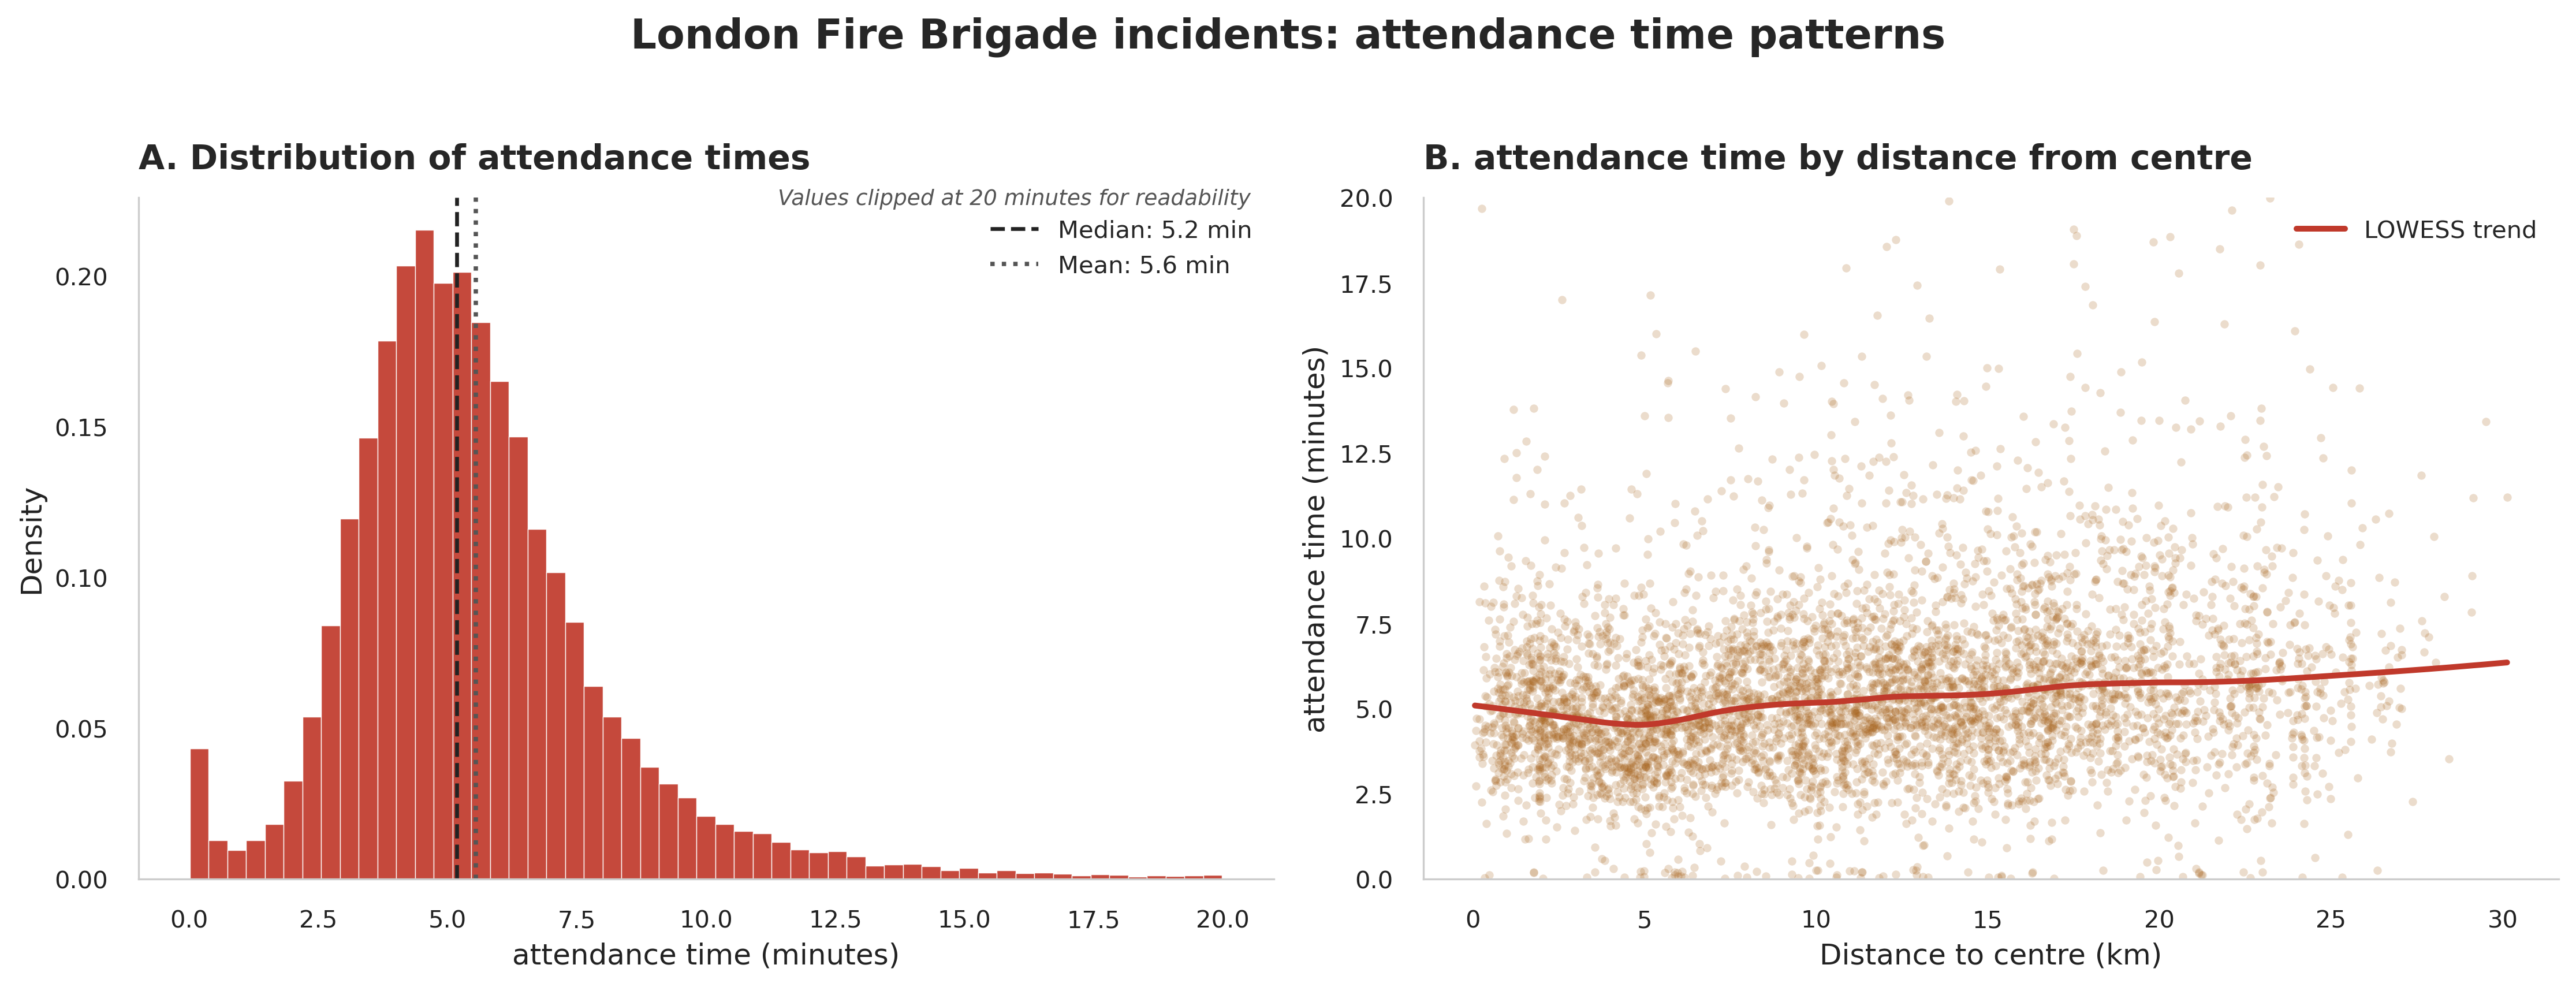

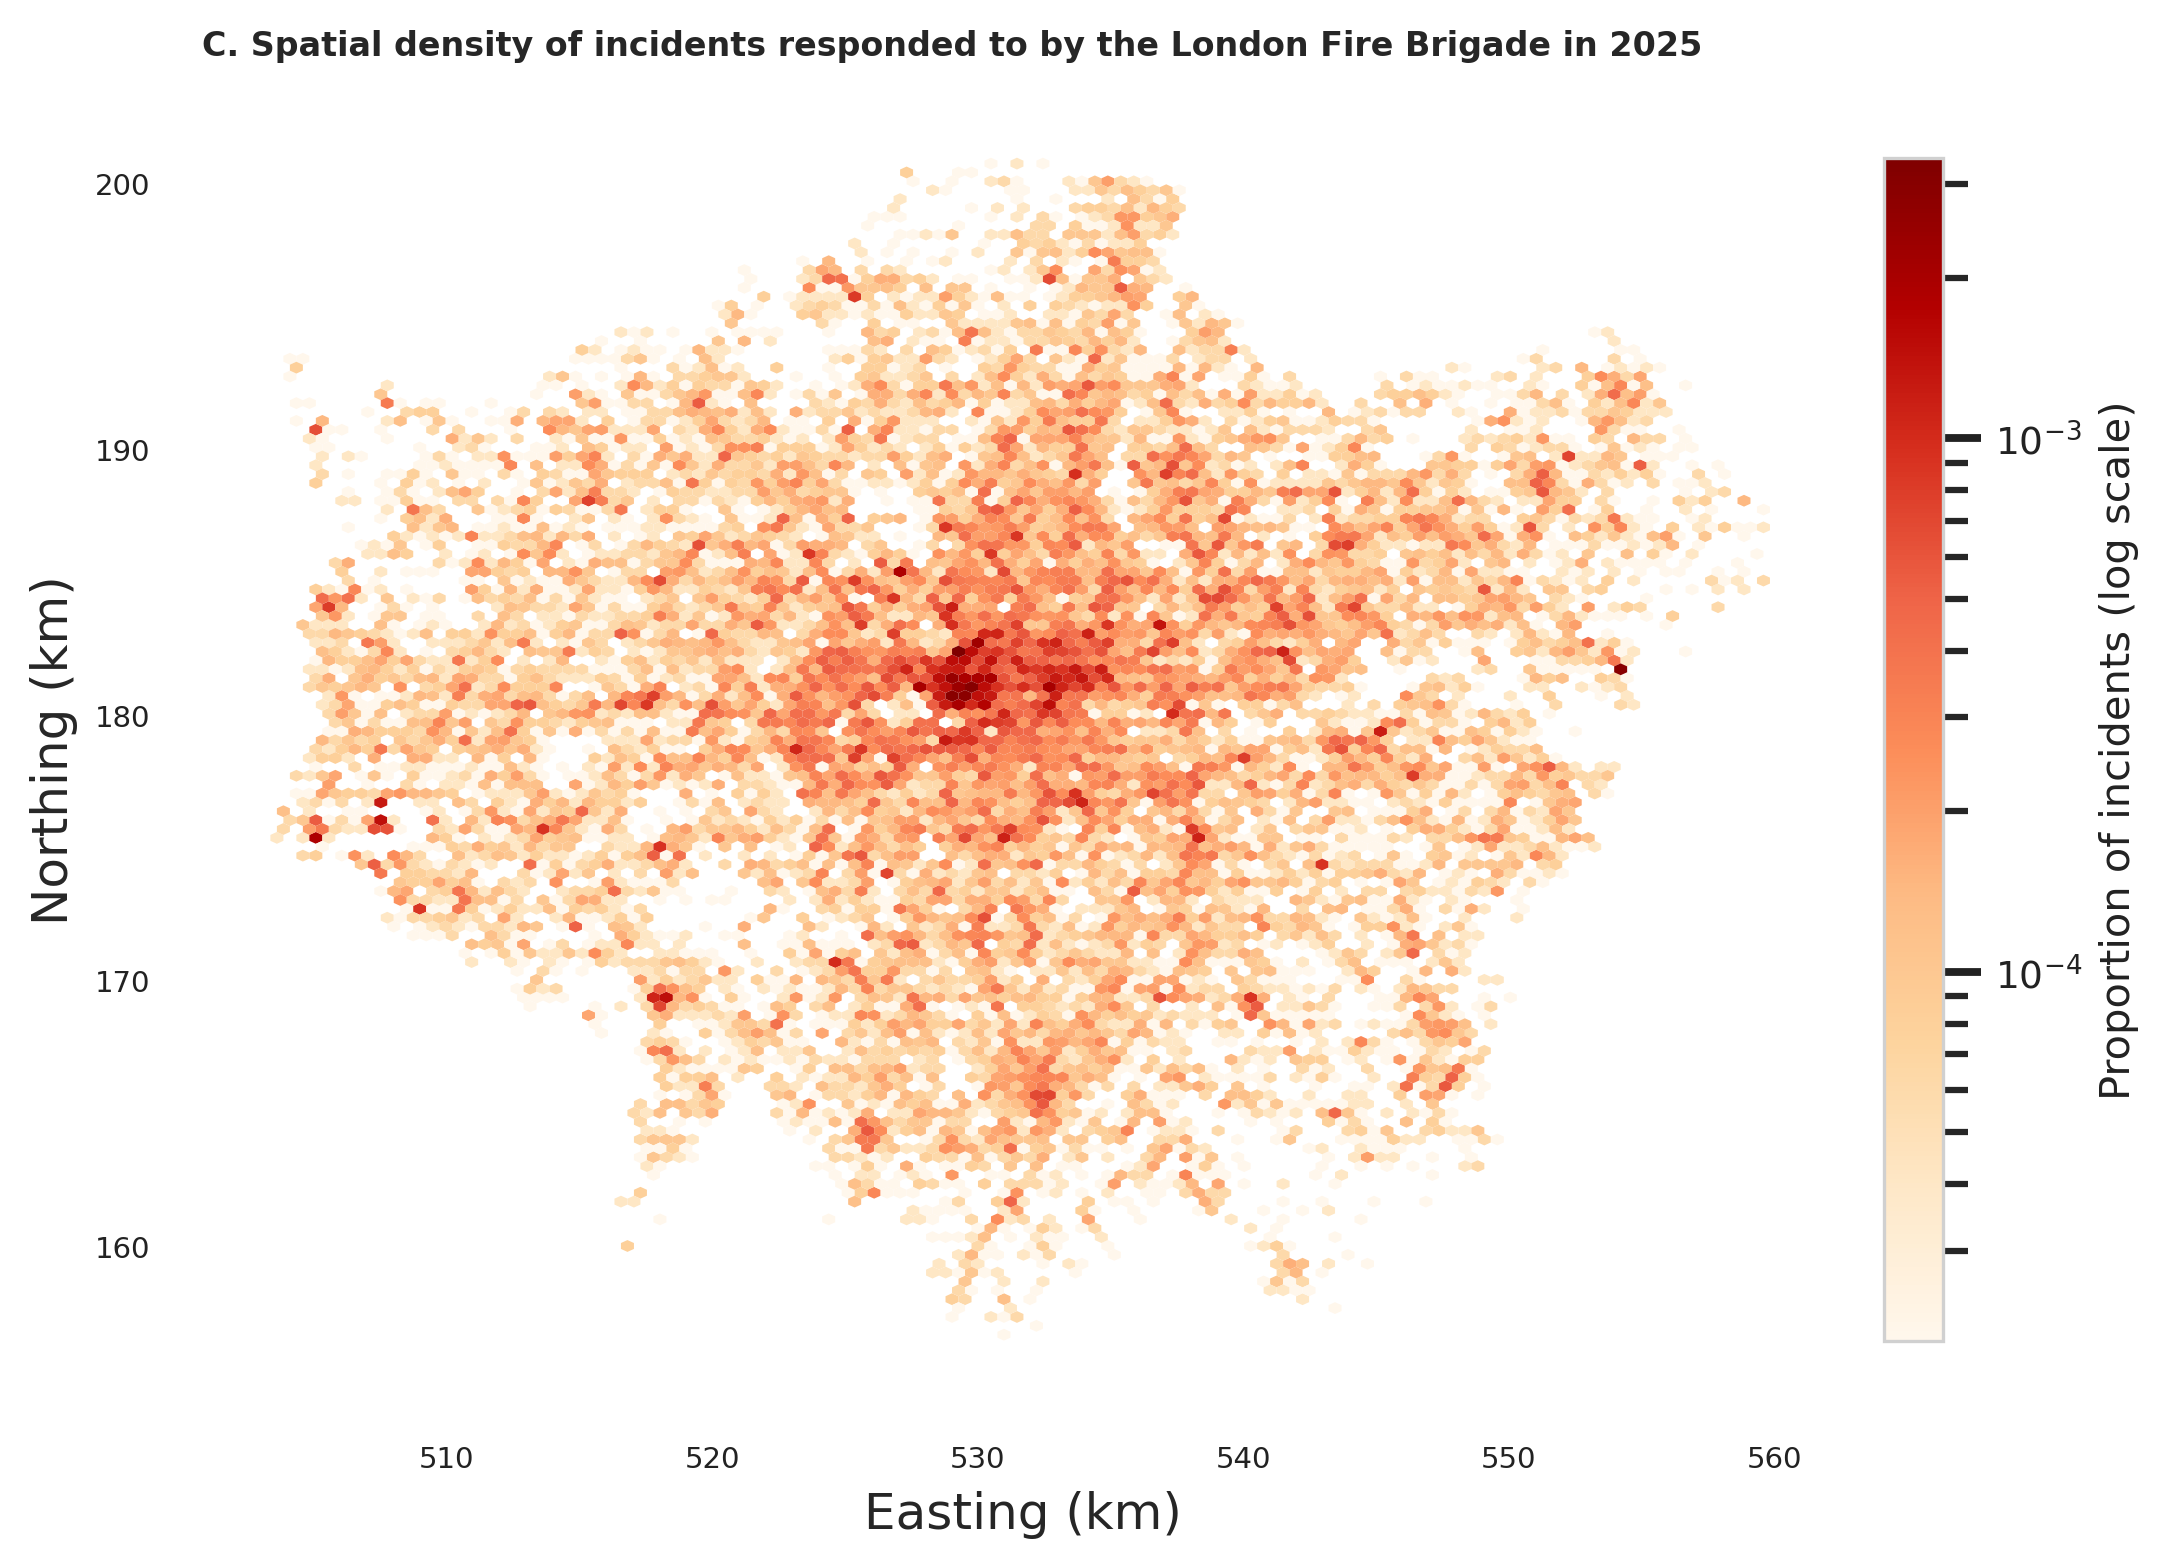

In [9]:
# -------------- visualisation of incident data ---------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300, facecolor="white")

# (a) attendance time histogram
ax1 = axes[0]
rt = LFB_incidents_25["attendance_time"].clip(upper=20)

ax1.hist(
    rt,
    bins=55,
    color=REPORT_COLOUR,
    edgecolor="white",
    linewidth=0.35,
    density=True,
    alpha=0.92,
)
ax1.axvline(
    rt.median(),
    color=DARK_TEXT,
    linestyle="--",
    linewidth=1.6,
    label=f"Median: {rt.median():.1f} min",
)
ax1.axvline(
    rt.mean(),
    color=MID_TEXT,
    linestyle=":",
    linewidth=1.8,
    label=f"Mean: {rt.mean():.1f} min",
)
ax1.set_xlabel("attendance time (minutes)")
ax1.set_ylabel("Density")
ax1.set_title("A. Distribution of attendance times", loc="left", pad=12)
ax1.legend(frameon=False, loc="upper right")
ax1.annotate(
    "Values clipped at 20 minutes for readability",
    xy=(0.98, 0.99),
    xycoords="axes fraction",
    ha="right",
    fontsize=9,
    color=MID_TEXT,
    style="italic",
)
style_report_axis(ax1)

# (b) attendance time vs distance to centre
ax2 = axes[1]
sample = (
    LFB_incidents_25[["distancetocentre_km", "attendance_time"]]
    .dropna()
    .sample(min(5000, len(LFB_incidents_25)), random_state=42)
)

ax2.scatter(
    sample["distancetocentre_km"],
    sample["attendance_time"],
    alpha=0.22,
    s=12,
    color="#A6611A",
    linewidths=0,
    rasterized=True,
)

from statsmodels.nonparametric.smoothers_lowess import lowess
trend = lowess(sample["attendance_time"], sample["distancetocentre_km"], frac=0.3)
ax2.plot(trend[:, 0], trend[:, 1], color=REPORT_COLOUR, linewidth=2.4, label="LOWESS trend")

ax2.set_xlabel("Distance to centre (km)")
ax2.set_ylabel("attendance time (minutes)")
ax2.set_ylim(0, 20)
ax2.set_title("B. attendance time by distance from centre", loc="left", pad=12)
ax2.legend(frameon=False, loc="upper right")
style_report_axis(ax2)

fig.suptitle("London Fire Brigade incidents: attendance time patterns", fontsize=17, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig("fig2_attendance_time_distance.png", bbox_inches="tight")
plt.show()

# (c) incident density hexbin
fig, ax = plt.subplots(figsize=(7.5, 5.8), dpi=300, facecolor="white")

total = len(LFB_incidents_25)

hb = ax.hexbin(
    LFB_incidents_25.geometry.x,
    LFB_incidents_25.geometry.y,
    C=np.ones(total) / total,
    reduce_C_function=np.sum,
    gridsize=115,
    cmap="OrRd",
    mincnt=1,
    linewidths=0,
    norm=mpl.colors.LogNorm(), # log scale is used because linear scale will wash out spatial variation 
)
cb = fig.colorbar(hb, ax=ax, shrink=0.74, pad=0.02)
cb.set_label("Proportion of incidents (log scale)", fontsize=10, color=DARK_TEXT)
cb.ax.tick_params(labelsize=9, colors=DARK_TEXT)

ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_title("C. Spatial density of incidents responded to by the London Fire Brigade in 2025", loc="left", pad=12, size=8)
ax.spines[:].set_visible(False)
ax.tick_params(colors=DARK_TEXT, labelsize=7)
ax.grid(False)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1000:.0f}"))

fig.tight_layout()
fig.savefig("fig2c_incident_density.png", bbox_inches="tight")
plt.show()

**Figure 2** **a.** Histogram showing the distribution of attendance times. **b.** Scatter plot showing the relationship between attendance time and distance from central London. **c.** Hexbin map showing the spatial density of incidents across London.

Attendance times show a right-skewed distribution and few incidents experience delays. Although the proportion of incients occur mostly in central London the relationship between distance from the city centre and attendance time is weak, suggesting that attendance time variation is influenced by additional factors. This supports the use of XGBoost which can better capture uneven and non-linear patterns within data.

In [10]:
# ------------------- LFB station records -------------------------------

# checking shape of the data to confirm that they match the number of stations in London: 103
print(f"In LFB stations there are {LFB_stations.shape[0]} rows and {LFB_stations.shape[1]} columns") 

#To check the stations were correctly processed and not just correctly named, I plotted them against a CartoDB basemap (independent from OSM) 
#and visually confirmed the positions looked right. Given the scope and time constraints of this project there was not much more that I could do

#LFB_stations.explore(popup='name', tooltip='name', tiles='CartoDB positron', marker_type='marker')

In LFB stations there are 103 rows and 2 columns


OS Open Roads was used to create a standardised road network for Dijkstra’s routing analysis. Restricted Local Access Roads were verified against the [OS Open Roads specification](https://docs.os.uk/os-downloads/products/transport-network-portfolio/os-open-roads/os-open-roads-technical-specification/code-lists-and-enumerations/roadfunctionvalue) and confirmed to be unrelated to LTN modal filters.

In [11]:
#  ----------------------- cleaning OS road links data -------------------- 
# checking for duplicates

#os_london_road_links 

#print(f"There are {os_london_road_links.duplicated(subset=['id']).sum()} duplicate rows on id")

#os_london_road_links["road_classification"].unique() #road classification had many unclassified roads 
# which came up with a classification on road function so so will use that instead

#os_london_road_links["road_classification"].unique()

# The function below applies the methodology of Urfalı and Eymen (2025) to clean the road network data

def clean_road_geometry(gdf, id_col='id', road_class_col='road_function', 
                         length_threshold=5, expected_classes=None,
                         keep_largest_component=True):
    """Clean road geometries with fewer Python loops and less memory pressure."""
    gdf = gdf.copy()
    report = {}

    # 1. Invalid geometries: only repair invalid rows
    invalid_mask = ~gdf.geometry.is_valid
    report['invalid_geometries_fixed'] = int(invalid_mask.sum())
    if invalid_mask.any():
        gdf.loc[invalid_mask, 'geometry'] = gdf.loc[invalid_mask, 'geometry'].apply(make_valid)

    # 2. Duplicate road segments
    dupe_count = gdf.duplicated(subset=[id_col]).sum()
    gdf = gdf.drop_duplicates(subset=[id_col])
    report['duplicate_segments_dropped'] = int(dupe_count)

    # 3. Explode MultiLineStrings before measuring length
    multi_count = (gdf.geometry.geom_type == 'MultiLineString').sum()
    if multi_count > 0:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    report['multilinestrings_exploded'] = int(multi_count)

    # Keep LineStrings only
    gdf = gdf[gdf.geometry.geom_type == 'LineString'].reset_index(drop=True)

    # 4. Tiny roads
    gdf['length_m'] = gdf.geometry.length
    tiny_count = (gdf['length_m'] < length_threshold).sum()
    gdf = gdf[gdf['length_m'] >= length_threshold].copy()
    report['tiny_segments_dropped'] = int(tiny_count)

    # 5. Missing or strange road classes before graph work, so the graph is smaller
    if road_class_col in gdf.columns:
        missing_class = gdf[road_class_col].isna().sum()
        report['missing_road_class'] = int(missing_class)
        gdf = gdf.dropna(subset=[road_class_col])

        if expected_classes:
            strange = ~gdf[road_class_col].isin(expected_classes)
            report['unexpected_road_classes'] = int(strange.sum())
            gdf = gdf[~strange]
    else:
        report['missing_road_class'] = f"Column '{road_class_col}' not found"

    # 6. Add endpoint coordinates once, then reuse later for NetworkX and KDTree
    coords = gdf.geometry.apply(lambda geom: (geom.coords[0], geom.coords[-1]))
    gdf['start_xy'] = coords.apply(lambda x: x[0])
    gdf['end_xy'] = coords.apply(lambda x: x[1])

    # 7. largest connected component filtering
    # This can be memory-heavy, but doing it after filtering keeps it smaller.
    if keep_largest_component and len(gdf) > 0:
        G_tmp = nx.Graph()
        G_tmp.add_edges_from(zip(gdf['start_xy'], gdf['end_xy']))
        components = list(nx.connected_components(G_tmp))
        if components:
            largest = max(components, key=len)
            report['disconnected_components'] = len(components)
            before = len(gdf)
            mask = gdf['start_xy'].isin(largest) & gdf['end_xy'].isin(largest)
            gdf = gdf.loc[mask].copy()
            report['fragments_removed'] = int(before - len(gdf))
        del G_tmp
        gc.collect()
    else:
        report['disconnected_components'] = 0
        report['fragments_removed'] = 0

    print("=== Road Network Cleaning Report ===")
    for key, val in report.items():
        print(f"  {key:<35}: {val}")
    print(f"  {'final_segment_count':<35}: {gdf.shape[0]}")

    return gdf
    
cleaned_roads = clean_road_geometry(
    os_london_road_links,
    id_col='id',
    road_class_col='road_function',
    length_threshold=5,
    expected_classes=['A Road', 'B Road', 'Minor Road', 'Local Road', 
                      'Local Access Road', 'Restricted Local Access Road', 
                      'Secondary Access Road', 'Motorway'],
    keep_largest_component=True
)

# Only keep columns used later. Keeping fewer columns saves memory.
cleaned_roads = cleaned_roads[['road_function', 'start_node', 'end_node', 'length', 'geometry', 'start_xy', 'end_xy']].copy()

speed_map = {
    'Motorway': 112,
    'A Road': 80,
    'B Road': 60,
    'Minor Road': 50,
    'Local Road': 30,
    'Local Access Road': 32,
    'Restricted Local Access Road': 32,
    'Secondary Access Road': 32,
}

cleaned_roads['speed_kmh'] = cleaned_roads['road_function'].map(speed_map).fillna(30).astype('float32')
cleaned_roads['travel_time_s'] = (cleaned_roads['length'] / (cleaned_roads['speed_kmh'] * 1000 / 3600)).astype('float32')

#print(cleaned_roads.columns.tolist())

# No routing failures occur, so the calculated ideal 
# travel times are retained for further analysis.

=== Road Network Cleaning Report ===
  invalid_geometries_fixed           : 0
  duplicate_segments_dropped         : 0
  multilinestrings_exploded          : 211336
  tiny_segments_dropped              : 1854
  missing_road_class                 : 0
  unexpected_road_classes            : 0
  disconnected_components            : 266
  fragments_removed                  : 843
  final_segment_count                : 208673


Now total street length of each road classification is plotted to identify which road types make up the largest proportion of London’s road network.

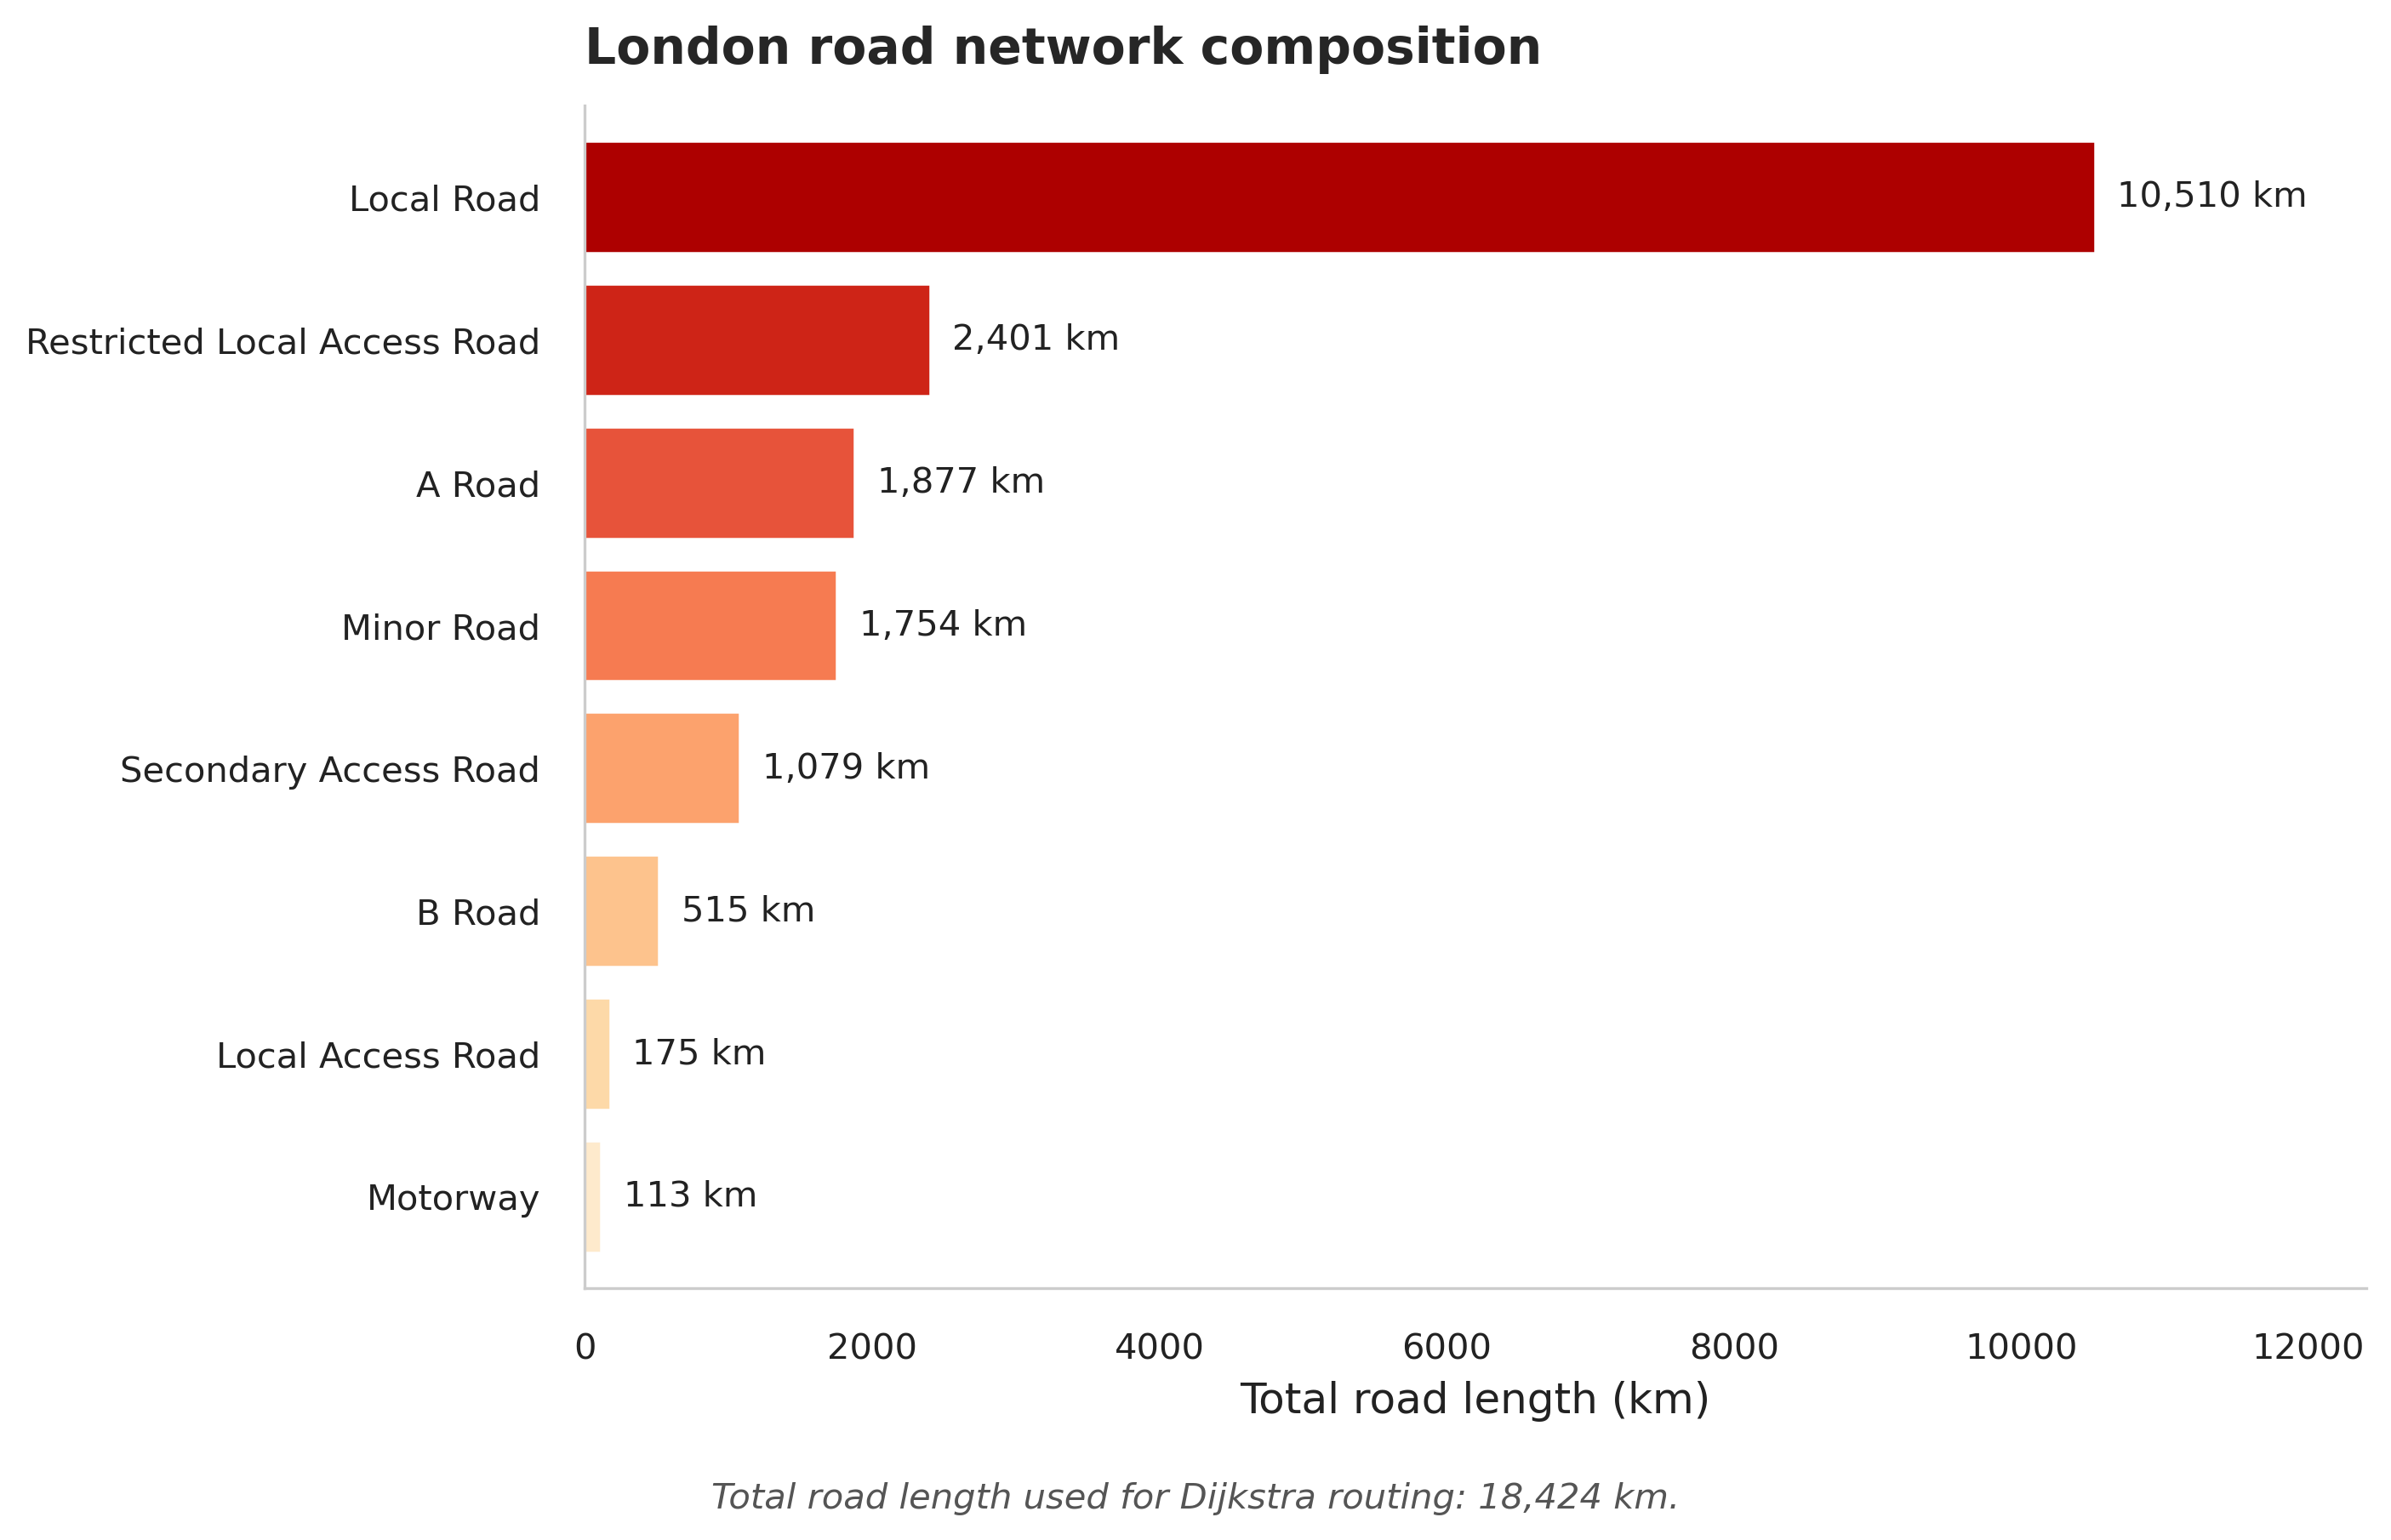

In [12]:
# ------------- Visualising London Road network --------------

road_length = (
    cleaned_roads
    .groupby("road_function")["length"]
    .sum()
    .div(1000)
    .sort_values()
)
road_length.index.name = "Road class"

fig, ax = plt.subplots(figsize=(9.5, 5.8), dpi=300, facecolor="white")

colours = sns.color_palette("OrRd", n_colors=len(road_length))
road_length.plot(
    kind="barh",
    ax=ax,
    color=colours,
    edgecolor="white",
    linewidth=0.6,
    width=0.78,
)

ax.set_xlabel("Total road length (km)")
ax.set_ylabel("")
ax.set_title("London road network composition", loc="left", pad=12)
style_report_axis(ax)

# Annotate each bar with total km; dynamic offset keeps labels away from bars.
offset = road_length.max() * 0.015
for i, value in enumerate(road_length):
    ax.text(
        value + offset,
        i,
        f"{value:,.0f} km",
        va="center",
        fontsize=10,
        color=DARK_TEXT,
    )

ax.set_xlim(0, road_length.max() * 1.18)
fig.text(
    0.5,
    -0.03,
    f"Total road length used for Dijkstra routing: {road_length.sum():,.0f} km.",
    ha="center",
    fontsize=10,
    color=MID_TEXT,
    style="italic",
)

fig.tight_layout()
fig.savefig("road_network_composition.png", bbox_inches="tight")
plt.show()


**Figure 3.** Composition of the London road network by road classification.

Minor and local roads account for most of London’s road network, suggesting that emergency attendance may be influenced by local street connectivity. Factors such as junction density, street layout complexity, and neighbourhood accessibility may therefore affect attendance times across the city. 


The next stage cleans and reduces the LTN dataset to variables relevant for subsequent modelling.

In [13]:
# ------------ cleaning Low Traffic Neighbourhood data ----------------

#print(ltn_filters_20_24)
#print(ltn_filters_20_24.columns)  # some of the column names are cut off at the end

# renaming the incomplete column names for future readability

ltn_filters_20_24 = ltn_filters_20_24.rename(columns={
    "descriptio": "description",
    "enforcemen": "enforcement_type",
    "timed_enfo": "timed_enforcement",
    "exemption_": "exemption_details",
    "implementa": "implementation_date",
    "date_remov": "date_removed",
    "lga": "borough",
    "ltn": "ltn_name"
})

# check updated column names
#print(ltn_filters_20_24columns.tolist())

# checking for duplicates in geometry column
# Duplicate geometries would mean the same LTN area is counted twice in any spatial join, skewing the analysis.
# print(f"There are {ltn_filters_20_24.duplicated(subset=['id']).sum()} duplicate rows on ID")

# Show rows with duplicated IDs
ltn_filters_20_24[
    ltn_filters_20_24["id"].duplicated(keep=False)
]

# its the same filter so that will be removed

# Remove duplicate IDs, keeping the first occurrence
ltn_filters_20_24 = ltn_filters_20_24.drop_duplicates(
    subset="id",
    keep="first"
)


# print(f"There are {ltn_filters_20_24.duplicated(subset=['id']).sum()} duplicate rows on ID")


# examining the unique enforcement types to identify interventions that represent
# physical vehicle barriers likely to affect fire brigade access or routing
ltn_filters_20_24["enforcement_type"].unique() 

# ----------------- keep only physical vehicle filters -----------------

keep_filters = [
    "Filter-Barrier-Bollard",
    "Filter-Barrier",
    "Filter-Barrier-Planter",
    "Filter-Barrier-Plastic",
    "Barrier",
    "Filter Barrier",
    "Filter-Barrier Bollard",
    "Bus Gate"
]

ltn_filters_20_24 = ltn_filters_20_24[
    ltn_filters_20_24["enforcement_type"].isin(keep_filters)
].copy()

# check remaining categories
#print(ltn_filters_20_24["enforcement"].unique())
#print(f"\nRemaining filters: {len(ltn_filters_20_24)}")


# selecting columns useful for analysis or mapping
ltn_filters_20_24 = ltn_filters_20_24[['enforcement_type', 'geometry']]


## 3.2 Feature engineering

### 3.2.1 Road-Network Construction and Dijkstra Routing 

In [14]:
# ------------------- Road-Network Construction and Dijkstra Routing ---------------------
# Build the graph once, snap all incidents at once, then run Dijkstra once per station.
# This avoids thousands of repeated shortest-path calls which initally killed the kernal when attempting to run.

# Build two-way edge table
edges_forward = cleaned_roads[['start_node', 'end_node', 'travel_time_s']].rename(
    columns={'start_node': 'source', 'end_node': 'target', 'travel_time_s': 'weight'}
)
edges_reverse = cleaned_roads[['end_node', 'start_node', 'travel_time_s']].rename(
    columns={'end_node': 'source', 'start_node': 'target', 'travel_time_s': 'weight'}
)
edges = pd.concat([edges_forward, edges_reverse], ignore_index=True)

G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)
print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Coordinate lookup from precomputed endpoint columns
node_coord_df = pd.concat([
    cleaned_roads[['start_node', 'start_xy']].rename(columns={'start_node': 'node', 'start_xy': 'xy'}),
    cleaned_roads[['end_node', 'end_xy']].rename(columns={'end_node': 'node', 'end_xy': 'xy'})
], ignore_index=True).drop_duplicates('node')

node_ids = node_coord_df['node'].to_numpy()
node_xy = np.vstack(node_coord_df['xy'].to_numpy())
tree = cKDTree(node_xy)

def nearest_nodes_for_points(geom_series):
    xy = np.column_stack([geom_series.x.to_numpy(), geom_series.y.to_numpy()])
    _, idx = tree.query(xy, k=1)
    return node_ids[idx]

# Clean station names to ensure that they match
LFB_incidents_25['station_clean'] = LFB_incidents_25['deployed_from_station'].astype(str).str.upper().str.strip()
LFB_stations['station_clean'] = LFB_stations['name'].astype(str).str.upper().str.strip()

# Snap stations and incidents to nearest graph nodes in vectorised batches
station_nearest_nodes = nearest_nodes_for_points(LFB_stations.geometry)
station_nodes = dict(zip(LFB_stations['station_clean'], station_nearest_nodes))
LFB_incidents_25['incident_node'] = nearest_nodes_for_points(LFB_incidents_25.geometry)

matched = LFB_incidents_25['station_clean'].isin(station_nodes.keys()).sum()
#print(f"Incidents with matched station: {matched}/{len(LFB_incidents_25)}")

# Run Dijkstra once per unique station used by incidents, not once per incident
LFB_incidents_25['idealtime_s'] = np.nan
missing_station_count = int((~LFB_incidents_25['station_clean'].isin(station_nodes.keys())).sum())
no_path_count = 0

print("\nCalculating ideal times by station — this may take a few minutes...")

for station in LFB_incidents_25['station_clean'].dropna().unique():
    source = station_nodes.get(station)
    if source is None:
        continue

    mask = LFB_incidents_25['station_clean'].eq(station)
    target_nodes = LFB_incidents_25.loc[mask, 'incident_node']

    # Single-source Dijkstra returns distances from this station to all reachable nodes.
    lengths = nx.single_source_dijkstra_path_length(G, source, weight='weight')
    vals = target_nodes.map(lengths)
    no_path_count += int(vals.isna().sum())
    LFB_incidents_25.loc[mask, 'idealtime_s'] = vals.to_numpy()

LFB_incidents_25['idealtime_min'] = LFB_incidents_25['idealtime_s'] / 60

print(f"\nIdeal time calculated for {LFB_incidents_25['idealtime_min'].notna().sum()} incidents")
print(f"No path failures: {no_path_count}")
print(LFB_incidents_25['idealtime_min'].describe())

# Free temporary objects no longer needed
# Keep G only if you need it later; otherwise delete it to release memory.
del edges_forward, edges_reverse, edges, node_coord_df, node_xy
gc.collect()

# No routing failures occur, so the calculated ideal travel times are retained for further analysis.

Graph built: 167859 nodes, 410172 edges

Calculating ideal times by station — this may take a few minutes...

Ideal time calculated for 49119 incidents
No path failures: 0
count    49119.000000
mean         2.566346
std          1.695937
min          0.000000
25%          1.367000
50%          2.220125
75%          3.398050
max         30.890751
Name: idealtime_min, dtype: float64


0

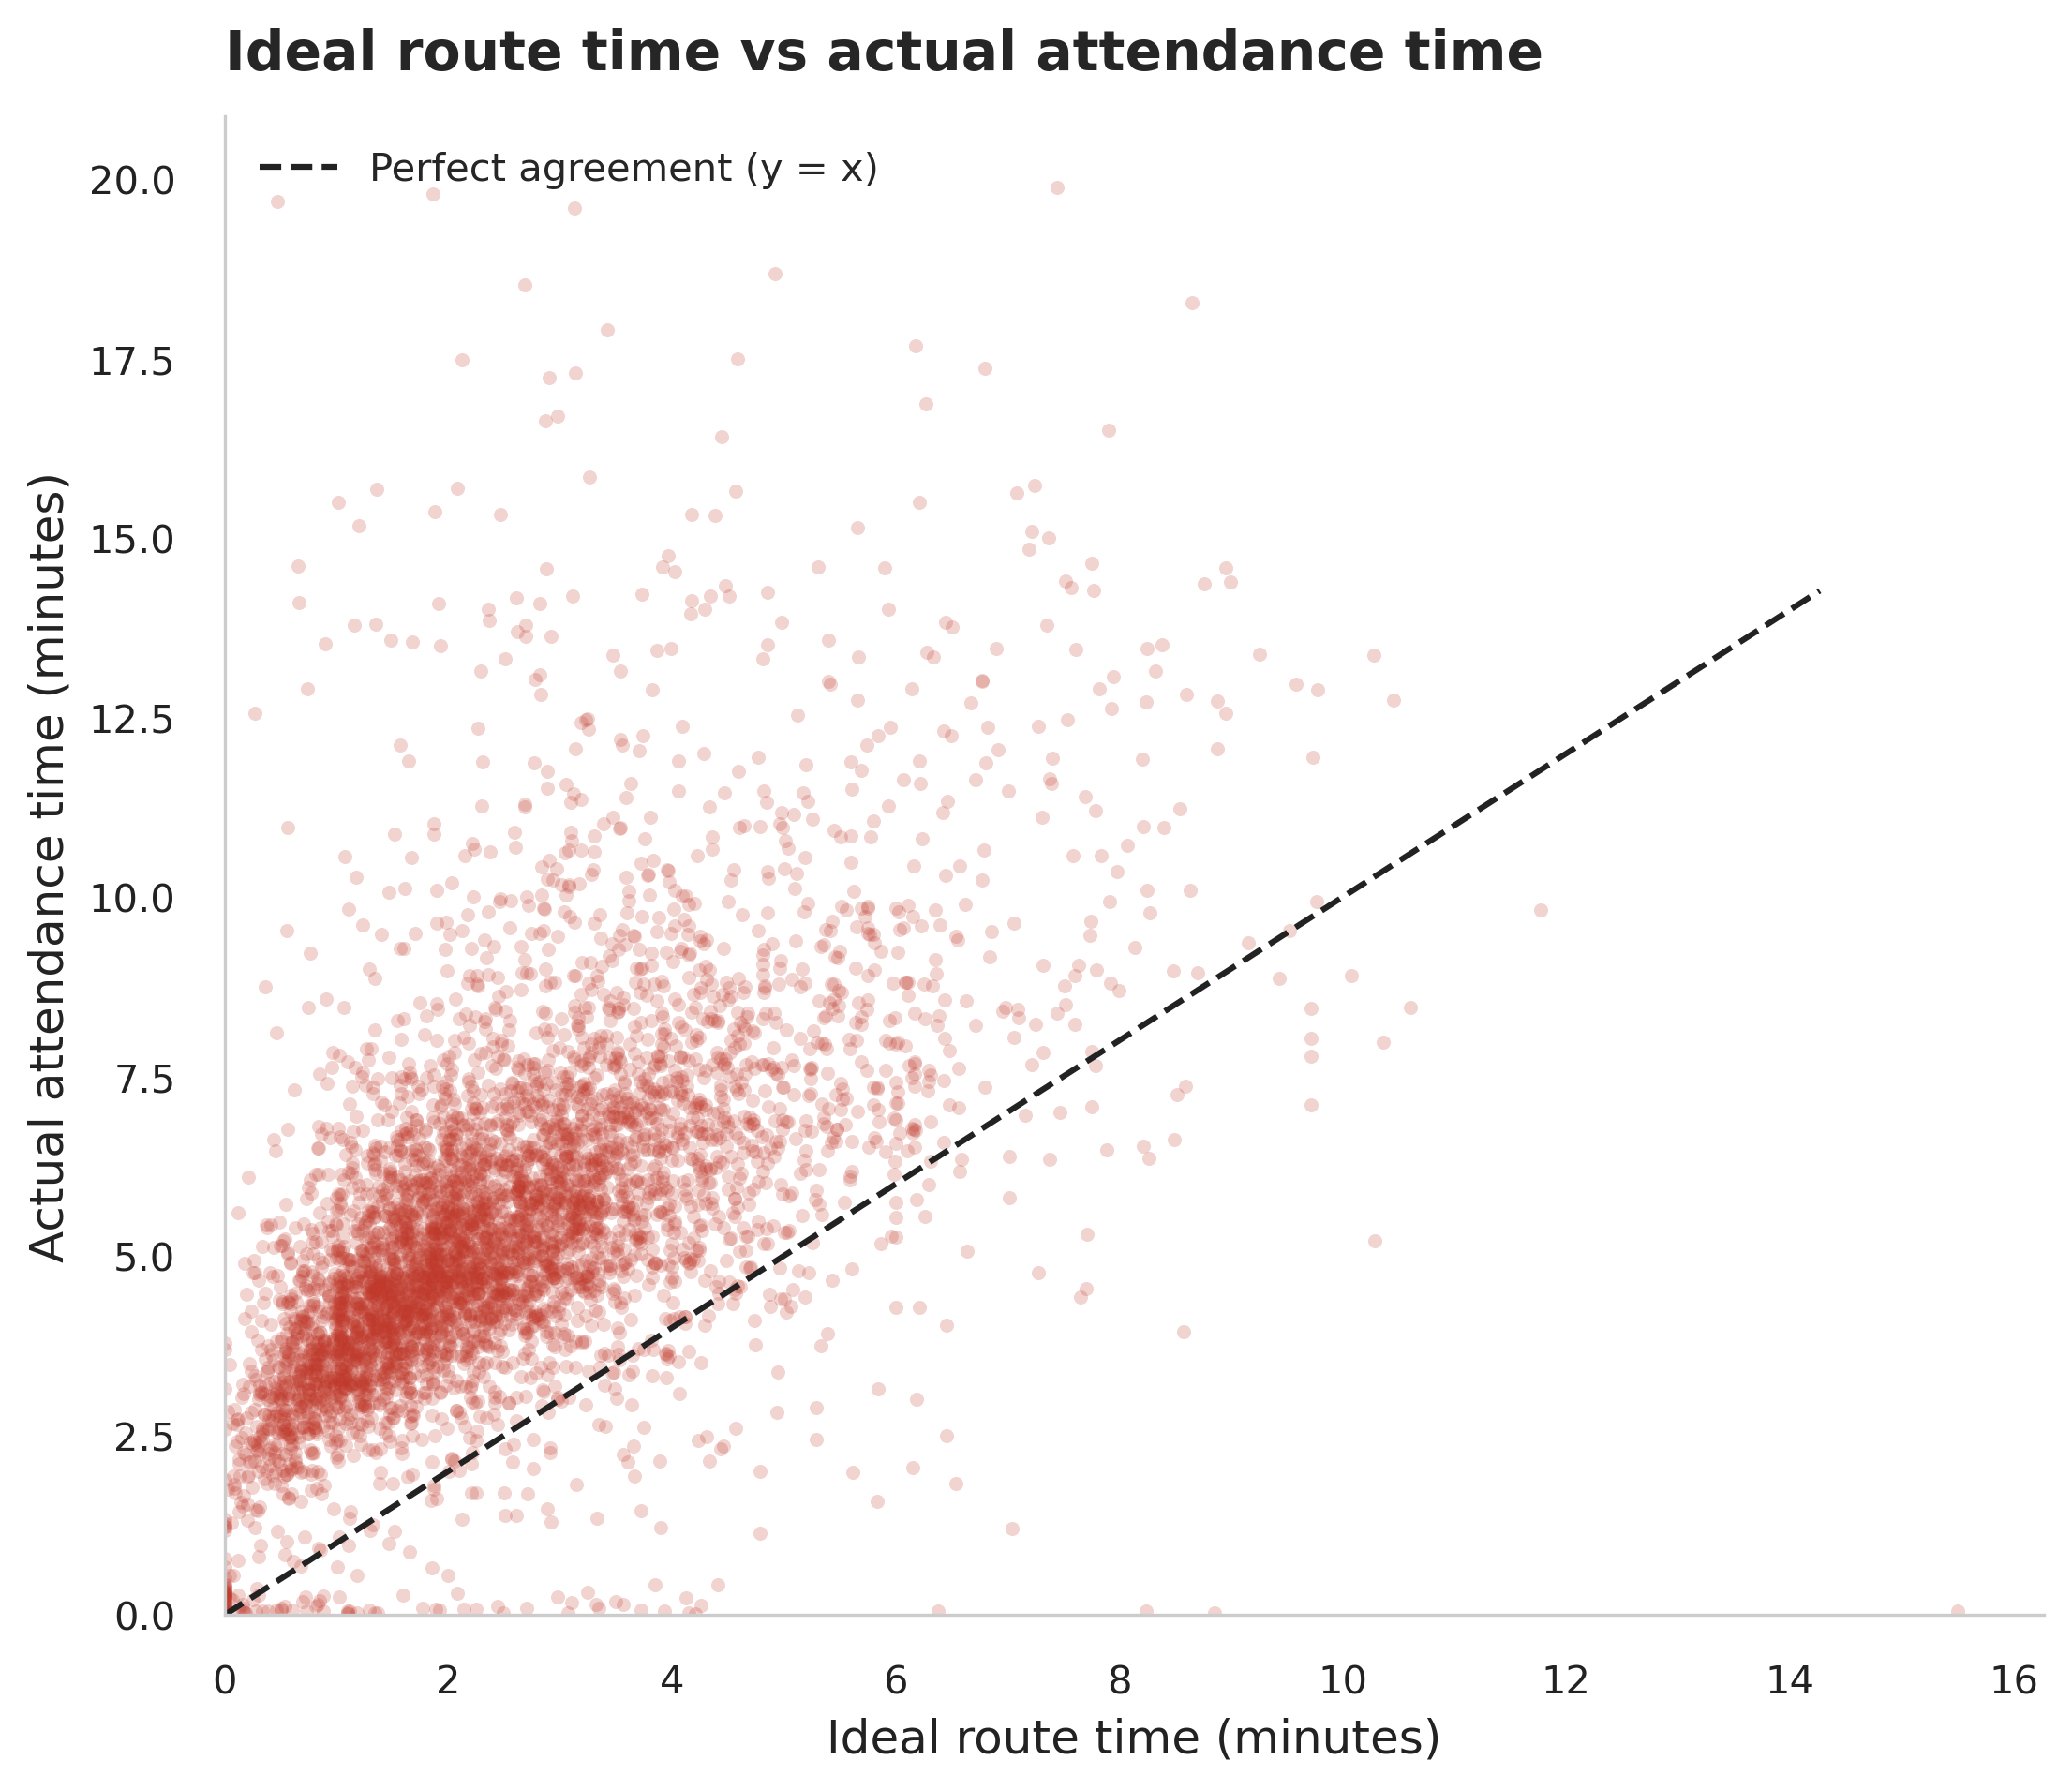

In [15]:
# ---------------- Comparing Ideal and Actual Route Times -------------

fig, ax = plt.subplots(figsize=(7.5, 6.5), dpi=300, facecolor="white")

sample = LFB_incidents_25[["idealtime_min", "attendance_time"]].dropna().sample(
    min(5000, len(LFB_incidents_25)), random_state=42
)

ax.scatter(
    sample["idealtime_min"],
    sample["attendance_time"],
    alpha=0.22,
    s=13,
    color=REPORT_COLOUR,
    linewidths=0,
    rasterized=True,
)

max_val = min(sample["idealtime_min"].max(), sample["attendance_time"].quantile(0.99))
ax.plot(
    [0, max_val],
    [0, max_val],
    color=DARK_TEXT,
    linestyle="--",
    linewidth=1.5,
    label="Perfect agreement (y = x)",
)

ax.set_xlabel("Ideal route time (minutes)")
ax.set_ylabel("Actual attendance time (minutes)")
ax.set_title("Ideal route time vs actual attendance time", loc="left", pad=12)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, loc="upper left")
style_report_axis(ax)

fig.tight_layout()
fig.savefig("fig4_dijkstra_scatter.png", bbox_inches="tight")
plt.show()


**Figure 4.** Comparison between ideal route time and actual London Fire Brigade attendance time.

Most incidents with ideal route times of 1–3 minutes recorded actual attendance times closer to 4–6 minutes, suggesting that additional factors such as traffic, operational delays, and LTNs may influence attendance times beyond ideal routing estimates. However, ideal route times provide a useful baseline measure of network accessibility, allowing the model to account for the minimum travel time between stations and incidents.

### 3.2.2 Using K Nearest Neighbours to predict Past Average Time

Because attendance times are similar within nearby areas, KNN was used to calculate a `past_avg_time` variable from surrounding historical incidents, allowing historical attendance patterns to be incorporated into the model.

In [16]:
def compute_past_avg_time(gdf, k_grid=[5, 10, 15, 20, 25, 30], max_history=5000, n_splits=3):
    """
    Computes past average attendance time for each incident using KNN regression.
    Incidents are sorted by date so each prediction uses only preceding incidents,
    preventing data leakage from future observations.
    Max_history limits the rolling window to avoid excessive memory usage.
    """
    # sort chronologically so past_avg only ever looks backwards
    gdf = gdf.sort_values('dateofcall').reset_index(drop=True)
    X = np.column_stack([gdf.geometry.x, gdf.geometry.y]).astype('float32')
    y = gdf['attendance_time'].to_numpy(dtype='float32')
    split = int(len(gdf) * 0.8)
    
    # tune k on training data only so test set does not influence feature engineering
    grid = GridSearchCV(
        KNeighborsRegressor(weights='distance'),
        param_grid={'n_neighbors': k_grid},
        cv=TimeSeriesSplit(n_splits=n_splits),  # time-aware CV preserves temporal order
        scoring='neg_mean_absolute_error',
        n_jobs=1
    )
    grid.fit(X[:split], y[:split])
    best_k = grid.best_params_['n_neighbors']
    print(f"Best k: {best_k} | CV MAE: {-grid.best_score_:.3f}")
    
    # compute past_avg_time for every incident using only its history
    # if time permitted, batched prediction could replace per-row fitting
    # while preserving the temporal ordering constraint
    past_avg = np.full(len(gdf), np.nan, dtype='float32')
    knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
    for i in range(best_k + 1, len(gdf)):
        start = max(0, i - max_history)  # rolling window caps memory usage
        knn.fit(X[start:i], y[start:i])
        past_avg[i] = knn.predict(X[i].reshape(1, -1))[0]
    
    gdf['past_avg_time'] = past_avg
    gdf = gdf.dropna(subset=['past_avg_time']).reset_index(drop=True)
    del X, y, past_avg; gc.collect()
    return gdf, best_k

LFB_incidents_25, best_k = compute_past_avg_time(LFB_incidents_25)

Best k: 30 | CV MAE: 1.641


### 3.2.3 Measuring Proximity to LTN Filters

Although network-based LTN exposure measures would provide greater precision, this approach was used due to time and computational constraints.

In [17]:
def count_filters_within_radius(incidents_gdf, filters_gdf, radii_dict):
    """
    Count LTN filters within specified radii of each incident using KDTree.
    Assumes both GeoDataFrames are already projected in metres (EPSG:27700).
    """
    filter_coords = np.array([(geom.x, geom.y) for geom in filters_gdf.geometry])
    incident_coords = np.array([(geom.x, geom.y) for geom in incidents_gdf.geometry])
    tree = cKDTree(filter_coords)
    
    for col, radius in radii_dict.items():
        incidents_gdf[col] = tree.query_ball_point(incident_coords, r=radius, return_length=True)
    
    return incidents_gdf

# cumulative counts
radii = {
    "filters_0_500m": 500,
    "filters_0_2000m": 2000,
    "filters_0_5000m": 5000
}

LFB_incidents_25 = count_filters_within_radius(LFB_incidents_25, ltn_filters_20_24, radii)

# non-overlapping bands
LFB_incidents_25["filters_500_2000m"] = LFB_incidents_25["filters_0_2000m"] - LFB_incidents_25["filters_0_500m"]
LFB_incidents_25["filters_2000_5000m"] = LFB_incidents_25["filters_0_5000m"] - LFB_incidents_25["filters_0_2000m"]

# drop intermediate cumulative columns
LFB_incidents_25 = LFB_incidents_25.drop(columns=["filters_0_2000m", "filters_0_5000m"])

## Final Dataset 

In [18]:
# checking the data frame to ensure that it is clean and ready for modelling
LFB_incidents_25.head(5).style.hide(axis="index") 


incidentnumber,deployed_from_station,attendance_time,easting_m,northing_m,dateofcall,geometry,distancetocentre_km,station_clean,incident_node,idealtime_s,idealtime_min,past_avg_time,filters_0_500m,filters_500_2000m,filters_2000_5000m
054673-01042025,bexley fire station,3.633333,549939.000000,176149.000000,01-Apr-25,POINT (549939 176149),20.377442,BEXLEY FIRE STATION,77F9AFDA-2323-49DF-B514-17443D831AE4,106.796999,1.779950,6.634605,0,0,1
054674-01042025,mill hill fire station,6.733333,520275.000000,192971.000000,01-Apr-25,POINT (520275 192971),15.844437,MILL HILL FIRE STATION,233FCB61-8C76-4B98-923F-3F09BFA50334,127.839005,2.130650,5.653005,0,0,0
054679-01042025,sutton fire station,5.650000,525752.000000,164742.000000,01-Apr-25,POINT (525752 164742),16.312411,SUTTON FIRE STATION,AA89F6E5-CEDC-4D34-B0A9-CBFBF3264D38,172.541999,2.875700,5.781433,1,3,1
054777-01042025,chelsea fire station,1.416667,529129.000000,178287.000000,01-Apr-25,POINT (529129 178287),2.373818,CHELSEA FIRE STATION,56340032-177F-42F7-9C5B-3F181CCAA0A4,136.992003,2.283200,5.874089,0,0,77
054774-01042025,dagenham fire station,3.600000,550861.000000,186090.000000,01-Apr-25,POINT (550861 186090),21.574085,DAGENHAM FIRE STATION,25175C4C-855D-4AB0-8378-F3F4EE732E0A,118.815000,1.980250,6.994273,0,0,0


# 4.0 Results and discussion

[Back to contents](#Contents)

## 4.1 XGBoost Model

Hyperparameters were tuned using grid search with time-series cross-validation to improve model performance and reduce overfitting.

In [19]:
# The function below is used to train, tune, and evaluate both models for efficiency.

def train_xgb_model(model_data, features, target="attendance_time", model_name="Model"):

    # define hyperparameter combinations to test during tuning
    # not many were chosen to reduce computational intensity
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    # use time-series cross-validation to preserve chronological order
    tscv = TimeSeriesSplit(n_splits=5)

    # remove rows with missing values in the target or selected features
    # then sort incidents chronologically by date
    model_data = model_data.dropna(
        subset=[target] + features
    ).sort_values("dateofcall").copy()

    # define predictor variables (X) and target variable (y)
    X = model_data[features]
    y = model_data[target]

    # split dataset into 80% training data and 20% testing data
    # no random shuffling is used because this is time-series data
    split = int(len(model_data) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # perform grid search to find the best hyperparameter combination
    grid = GridSearchCV(
        estimator=XGBRegressor(
            random_state=42,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            n_jobs=-1
        ),
        param_grid=param_grid,
        cv=tscv,
        scoring="r2",
        n_jobs=1
    )

    # train all model combinations on the training data
    grid.fit(X_train, y_train)

    print(f"Best hyperparameters for {model_name}:")
    print(grid.best_params_)

    # train the final XGBoost model using the best parameters found
    model = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        **grid.best_params_
    )

    model.fit(X_train, y_train)

    # generate predictions on the unseen test dataset
    y_pred = model.predict(X_test)

    # evaluate model performance using regression metrics and accuracy ±3min
    # Which was used in Urfalı and Eymen (2025) and reflects the models practical applicability in 
    # response scenarios however such a tolerance remains substantial in emergency response contexts
    results = {
        "Model": model_name,
        "Test_R2": r2_score(y_test, y_pred),
        "Test_MSE": mean_squared_error(y_test, y_pred),
        "Test_MAE": mean_absolute_error(y_test, y_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Accuracy_±3min": (np.abs(y_test - y_pred) <= 3).mean() * 100
    }

    # print model evaluation results
    print("\nModel Performance:")
    for key, value in results.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")

    return model, results, X_train, X_test, y_test, y_pred

### Training the model without the Low Traffic Neighbourhood Features 

In [20]:
# ----------------- prepare XGBoost modelling data: without LTNs -----------------

# coordinates used by the baseline model
LFB_incidents_25["easting"] = LFB_incidents_25.geometry.x
LFB_incidents_25["northing"] = LFB_incidents_25.geometry.y

features_without_ltns = [
    "past_avg_time",
    "idealtime_min",
    "easting",
    "northing",
    "distancetocentre_km"
]

model_data_without_ltns = LFB_incidents_25.dropna(
    subset=["attendance_time"] + features_without_ltns
).sort_values("dateofcall").copy()

without_ltns_model, without_ltns_results, X_train_without_ltns, X_test_without_ltns, y_test_without_ltns, test_pred_without_ltns = train_xgb_model(
    model_data=model_data_without_ltns,
    features=features_without_ltns,
    model_name="XGBoost without LTNs"
)

Best hyperparameters for XGBoost without LTNs:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Model Performance:
Test_R2: 0.4162
Test_MSE: 3.7110
Test_MAE: 1.2731
Test_RMSE: 1.9264
Accuracy_±3min: 91.3730


### Training the model with the Low Traffic Neighbourhood Features 

In [21]:
# ----------------- prepare XGBoost modelling data: with LTNs -----------------

features_with_ltns = [
    "past_avg_time",
    "idealtime_min",
    "easting",
    "northing",
    "distancetocentre_km",
    "filters_0_500m",
    "filters_500_2000m",
    "filters_2000_5000m"
]

model_data_with_ltns = LFB_incidents_25.dropna(
    subset=["attendance_time"] + features_with_ltns
).sort_values("dateofcall").copy()

with_ltns_model, with_ltns_results, X_train_with_ltns, X_test_with_ltns, y_test_with_ltns, test_pred_with_ltns = train_xgb_model(
    model_data=model_data_with_ltns,
    features=features_with_ltns,
    model_name="XGBoost with LTNs"
)

Best hyperparameters for XGBoost with LTNs:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Model Performance:
Test_R2: 0.4200
Test_MSE: 3.6873
Test_MAE: 1.2698
Test_RMSE: 1.9202
Accuracy_±3min: 91.4952


In [22]:
# ----------------- model comparison table -----------------

results_table = pd.DataFrame([
    {"Model": "XGBoost without LTNs", **without_ltns_results},
    {"Model": "XGBoost with LTNs", **with_ltns_results}
])

# keep only desired columns
results_table = results_table[
    [
        "Model",
        "Test_R2",
        "Test_MSE",
        "Test_MAE",
        "Test_RMSE",
        "Accuracy_±3min"
    ]
]

# rename columns
results_table = results_table.rename(columns={
    "Test_R2": "R²",
    "Test_MSE": "MSE (min²)",
    "Test_MAE": "MAE (min)",
    "Test_RMSE": "RMSE (min)",
    "Accuracy_±3min": "Accuracy within ±3 min (%)"
})

display(
    results_table.style
    .hide(axis="index")
    .format({
        "R²": "{:.3f}",
        "MSE (min²)": "{:.2f}",
        "MAE (min)": "{:.2f}",
        "RMSE (min)": "{:.2f}",
        "Accuracy within ±3 min (%)": "{:.2f}"
    })
)

Model,R²,MSE (min²),MAE (min),RMSE (min),Accuracy within ±3 min (%)
XGBoost without LTNs,0.416,3.71,1.27,1.93,91.37
XGBoost with LTNs,0.420,3.69,1.27,1.92,91.50


**Table 2.** Performance comparison of the XGBoost models with and without LTN-related variables.


Without LTN variables, the model explains 41.6% of attendance-time variation (R² = 0.416). Incorporating LTN-related features increases explanatory power marginally to 42.0% (R² = 0.42), while RMSE decreases from 1.93 to 1.92 minutes and accuracy within ±3 minutes improves from 91.37% to 91.50%.

The small improvement suggests that LTN-related variables contribute only limited predictive value, although network accessibility and routing efficiency appear more influential. The relatively low R² values suggest that attendance times are influenced by variability beyond the available predictors, although the high ±3 minute accuracy indicates the model remains effective at approximating most incidents.


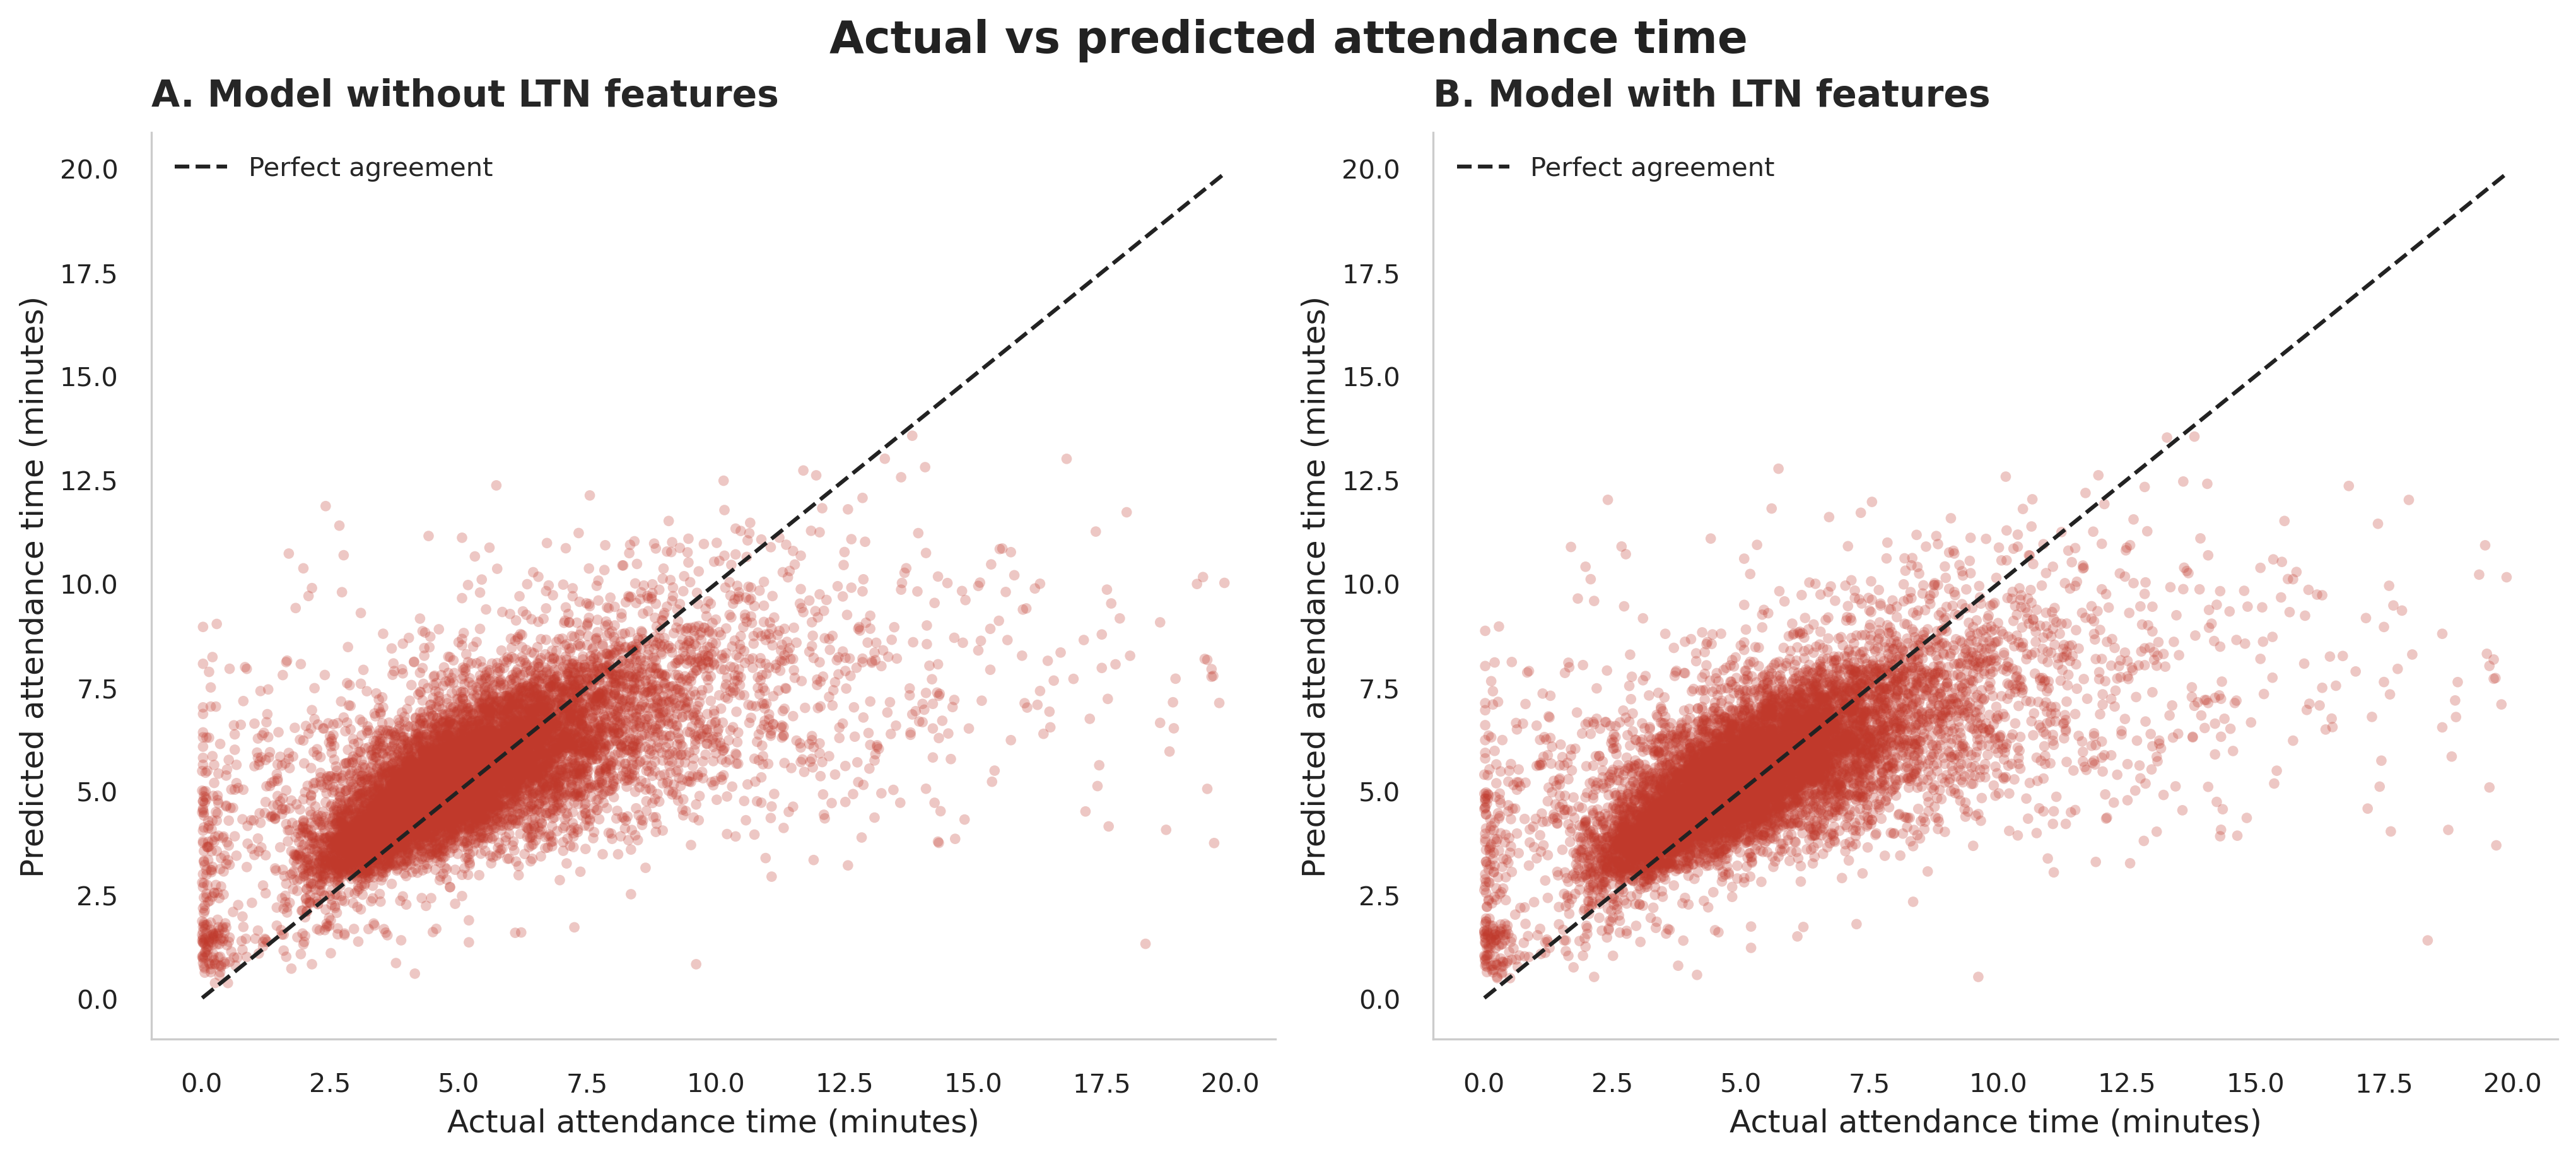

In [23]:
# ----------------- actual vs predicted attendance time -----------------
def plot_actual_vs_predicted(ax, actual, predicted, title):
    ax.scatter(
        actual,
        predicted,
        s=16,
        alpha=0.28,
        color=REPORT_COLOUR,
        edgecolor="none",
        rasterized=True,
    )
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color=DARK_TEXT,
        linestyle="--",
        linewidth=1.5,
        label="Perfect agreement",
    )
    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel("Actual attendance time (minutes)")
    ax.set_ylabel("Predicted attendance time (minutes)")
    ax.legend(frameon=False, loc="upper left")
    style_report_axis(ax)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), dpi=300, constrained_layout=True, facecolor="white")

plot_actual_vs_predicted(axes[0], y_test_without_ltns, test_pred_without_ltns, "A. Model without LTN features")
plot_actual_vs_predicted(axes[1], y_test_with_ltns, test_pred_with_ltns, "B. Model with LTN features")

fig.suptitle("Actual vs predicted attendance time", fontsize=17, fontweight="bold", color=DARK_TEXT)
fig.savefig("fig_actual_vs_predicted.png", bbox_inches="tight")
plt.show()


**Figure 6** **a.** Actual versus predicted attendance times for the XGBoost model without LTN features. **b.** Actual versus predicted attendance times for the XGBoost model with LTN features.

The models predict attendance times well between 3–8 minutes. However, prediction error increases for incidents above 10 minutes, where longer attendance times are consistently underestimated and fall below the 1:1 agreement line. This may reflect the difficulty of capturing operationally complex incidents using static routing and accessibility variables alone. The overall distribution and spread of predictions remain highly similar, reinforcing that LTN variables contribute only limited additional predictive value.

## 4.2 Feature importance Analysis

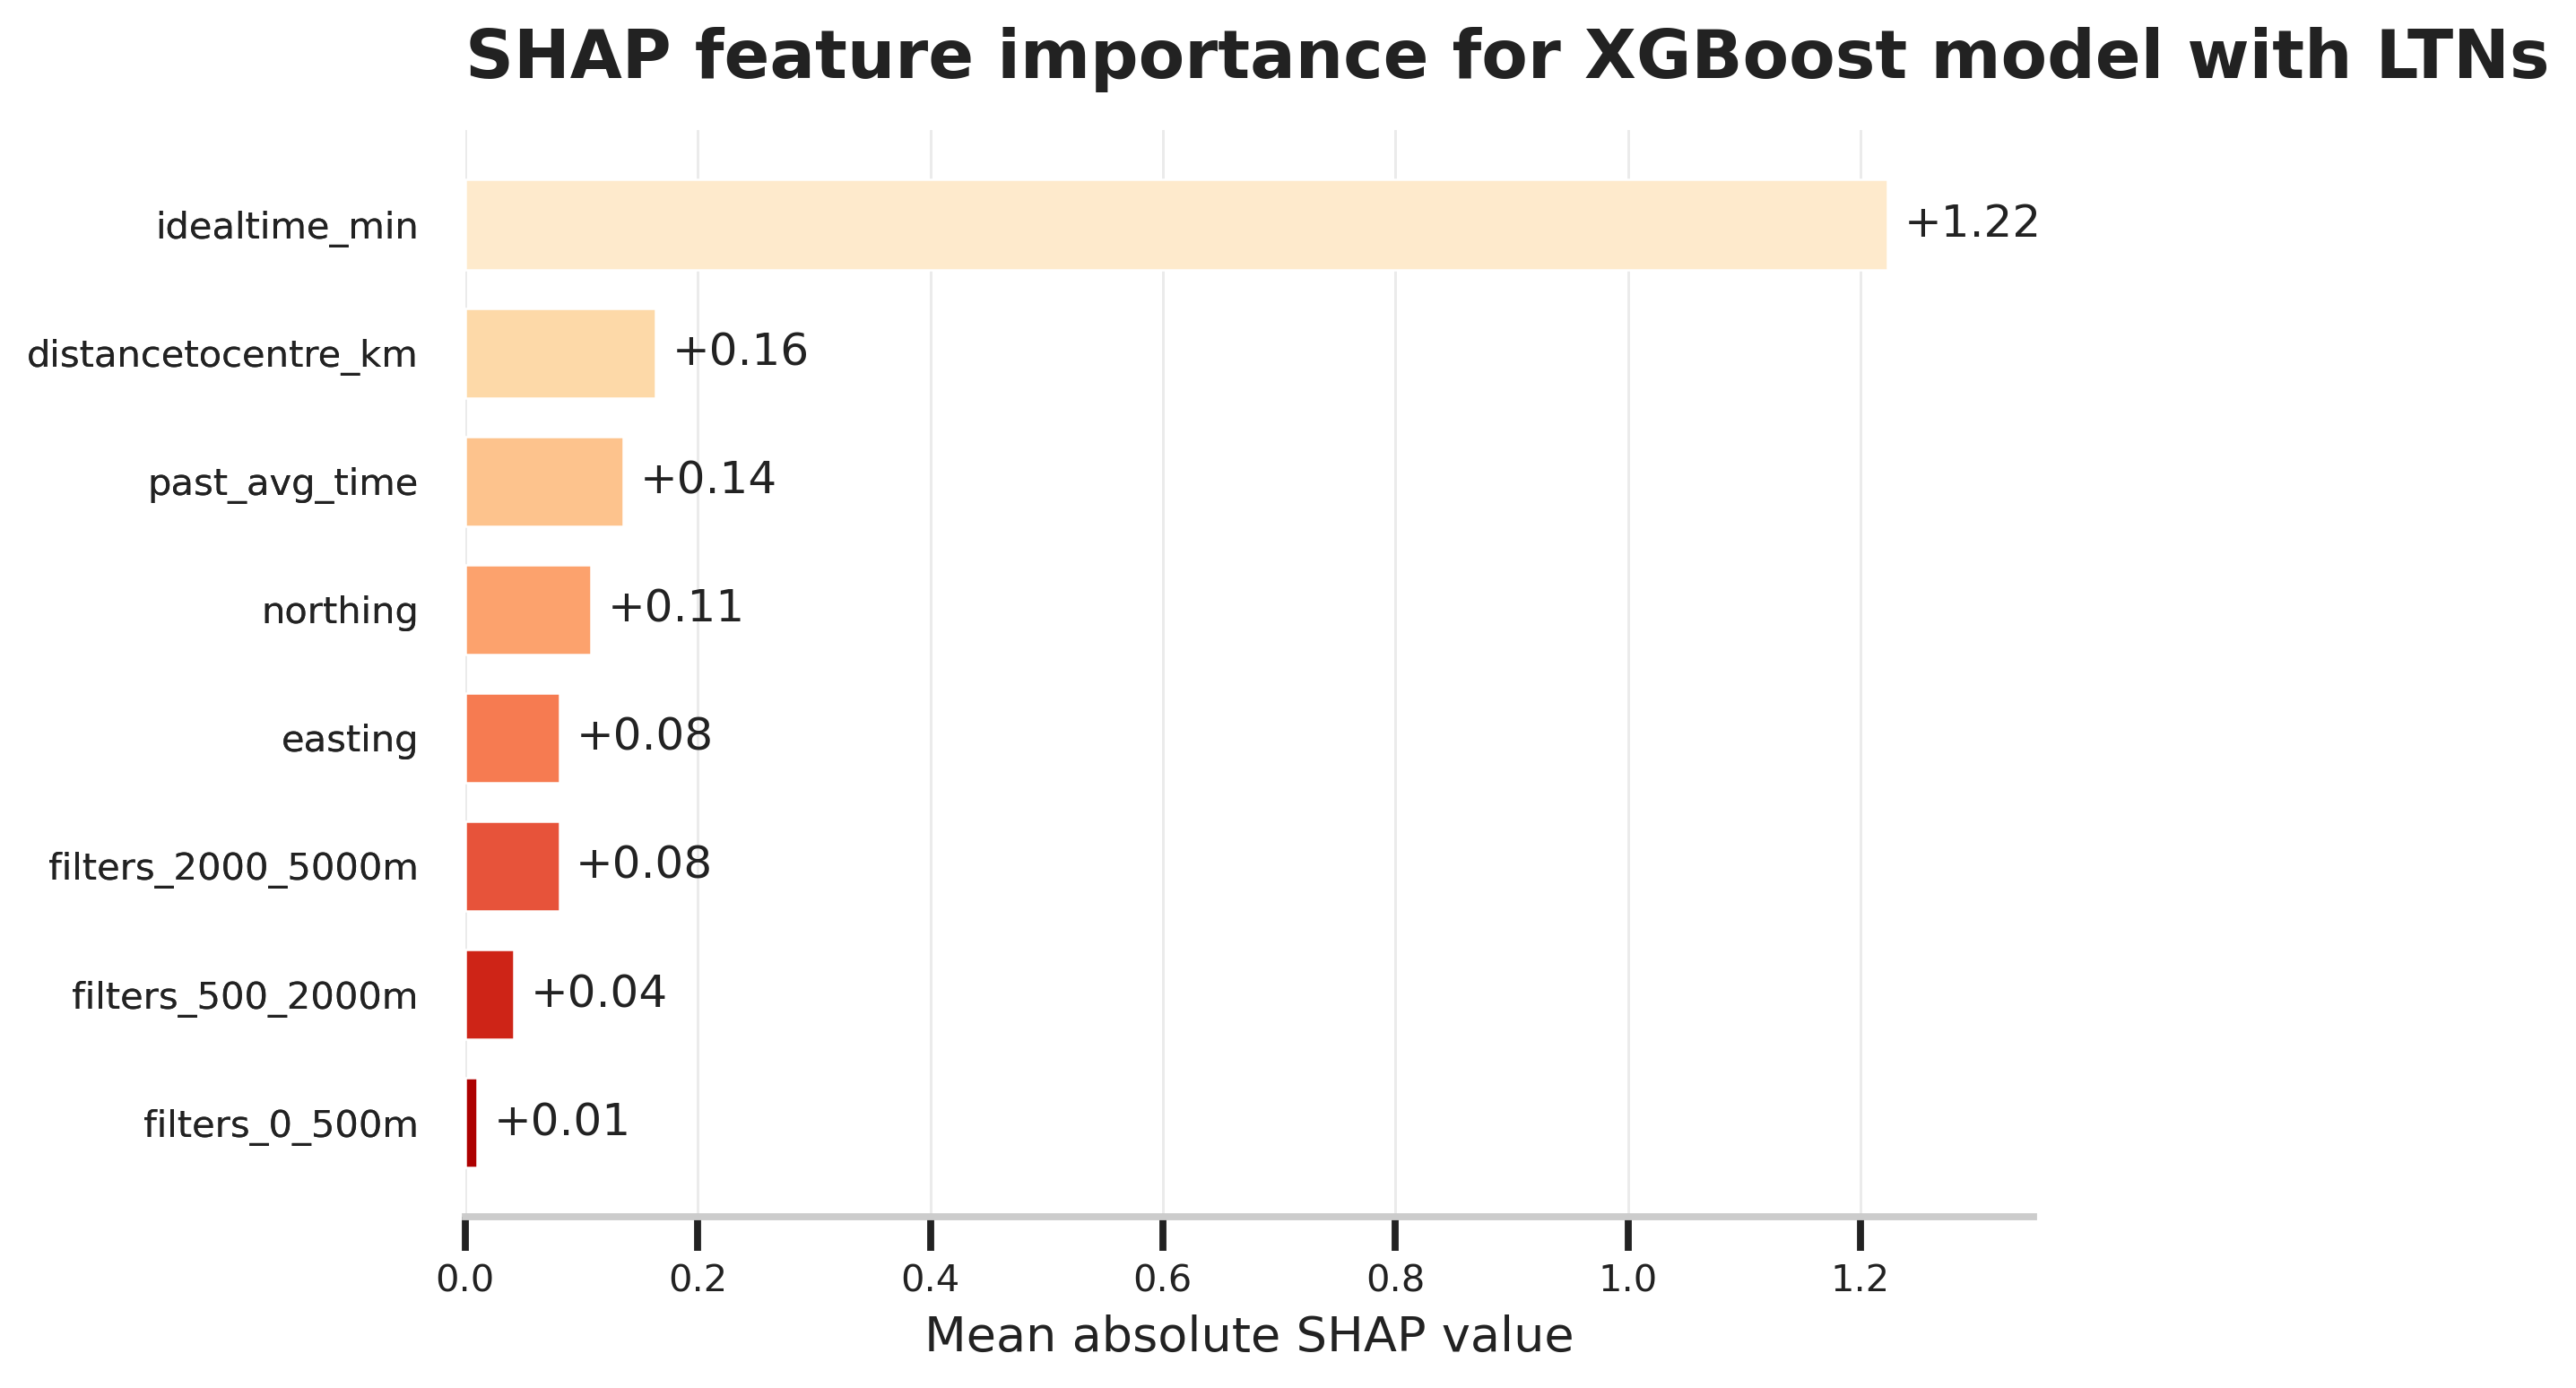

In [24]:
# ----------------- SHAP feature importance: with LTNs model -----------------

sns.set_theme(style="white", context="talk")

X_shap = X_test_with_ltns.sample(
    min(500, len(X_test_with_ltns)),
    random_state=42,
)

explainer = shap.Explainer(
    with_ltns_model,
    X_train_with_ltns,
)

shap_values = explainer(X_shap)

fig, ax = plt.subplots(figsize=(9.5, 6.5), dpi=300, facecolor="white")

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False,
)

ax = plt.gca()

# Remove default SHAP reference lines and recolour bars for consistency.
for line in ax.lines:
    line.set_visible(False)

shap_colours = sns.color_palette("OrRd", len(ax.patches))
for patch, colour in zip(ax.patches, shap_colours):
    patch.set_facecolor(colour)
    patch.set_edgecolor("white")
    patch.set_linewidth(0.6)

ax.grid(True, axis="x", color=GRID_COLOUR, linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)

ax.set_title(
    "SHAP feature importance for XGBoost model with LTNs",
    loc="left",
    pad=14,
)
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=10, colors=DARK_TEXT)

for text in ax.findobj(match=plt.Text):
    text.set_color(DARK_TEXT)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

fig.tight_layout()
fig.savefig("fig_shap_feature_importance.png", bbox_inches="tight")
plt.show()


**Figure 7.** SHAP feature importance for the XGBoost model including LTN variables. Features with larger mean absolute SHAP values have a greater overall influence on predicted attendance times.

Ideal travel time contributes most strongly to model performance (SHAP +1.22), suggesting that routing-based accessibility exerts greater influence on fire brigade response times than any other included factor. This contrasts with Urfalı and Eymen (2025), where historical attendance time contributed most strongly. Historical attendance time, distance from the centre, and coordinate location exert weaker secondary effects, while all LTN-related variables remain limited (SHAP < +0.10).


### 4.3 Limitations and future outlook

[Back to contents](#Contents)

The model does not account for factors such as real-time traffic congestion, weather conditions (Kox, 2018), or variation in road usage by time of day, which likely contribute to unexplained variation in attendance times and the relatively low R² value (~0.42). In addition, ideal travel times are based on estimated road-network routing rather than observed emergency vehicle movement data, meaning the model cannot capture congestion delays, road closures, or emergency driver routing decisions during incidents. LTN effects were also simplified into buffer-based filter density measures, which may not fully represent emergency vehicle movement in practice. 

Future research could incorporate real-time traffic data, traffic variation, and emergency vehicle GPS data to improve travel-time estimation. Applying feature selection methods such as permutation importance or RFECV before final model development may also improve model generalisability by reducing redundant spatial predictors. Integrating dynamic congestion into the routing network could further help identify areas at greater risk of delayed emergency access during road-network planning decisions (London Fire Brigade, 2021).

## 5.0 Conclusion

[Back to contents](#Contents)

This study aimed to address the following research questions:

**1.) Can fire brigade attendance times in London be predicted using spatial and incident characteristics?**  
attendance times were predicted with moderate accuracy (R² ≈ 0.42), demonstrating that spatial and incident variables explain a proportion of variation in London Fire Brigade attendance times.

**2.) Does incorporating proximity to LTN modal filters increase the proportion of variance explained by the model?**  
The inclusion of LTN variables produced only marginal improvements in model performance, suggesting that proximity to modal filters contributes limited explanatory value within the final model. 

The findings suggest that network accessibility has greater influence on emergency response performance than street-filtering measures, highlighting the importance of city-scale accessibility planning within transport and emergency-service policy.

## 6.0 References



Allin, S. (2020) ‘Ambulance crews impeded by low traffic schemes’, Enfield Dispatch. Available at: https://enfielddispatch.co.uk/ambulance-crews-impeded-by-low-traffic-schemes (Accessed: 01 May 2026).

Biggsy Travels (2018) Centre of London. Available at: https://biggsytravels.com/2018/04/01/centre-of-london (Accessed: 01 May 2026).

Carrier-Pilkington, L. (2026) ‘Traffic calming policies delayed’, South West Londoner. Available at: https://www.swlondoner.co.uk/news/16022026-traffic-calming-policies-delayed  (Accessed: 01 May 2026).

Cerna Ñahuis, S.L. (2022) Prediction of interventions and optimization of resources based on machine learning and operations research for fire departments, Université Bourgogne Franche-Comté. Available at: https://theses.hal.science/tel-04368508 (Accessed: 05 May 2026).

Grant, H. (2026) ‘Tower Hamlets mayor acted unlawfully over removal of LTN schemes’, The Guardian. Available at: https://www.theguardian.com/uk-news/2026/jan/22/tower-hamlets-mayor-acted-unlawfully-removal-ltn-schemes (Accessed: 01 May 2026).

Hartley, E. (2024) ‘Scientists look into London’s 2022 “firewaves”’, London: BBC News. Available at: https://www.bbc.co.uk/news/articles/c8rxgmmg4g7o (Accessed: 17 May 2026).

Kox, T., Lüder, C. and Gerhold, L. (2018) ‘Anticipation and attendance: emergency services in severe weather situations in Germany’, International Journal of Disaster Risk Science, 9(2), pp. 116–126. doi:10.1007/s13753-018-0170-2.

London Assembly Research Unit (2026) London Fire Brigade, London: Greater London Authority. Available at: https://www.london.gov.uk/who-we-are/what-london-assembly-does/london-assembly-research-unit-publications/london-fire-brigade (Accessed: 01 May 2026).

London Fire Brigade (2023) GN 29: Access for Fire Appliances (PDF), London: London Fire Brigade. Available at: https://www.london-fire.gov.uk/media/2341/gn_29_access_for_fire_appliances.pdf (Accessed: 01 May 2026).

Londonist (2014) Where is the centre of London? An update. Available at: https://londonist.com/2014/10/where-is-the-centre-of-london-an-update (Accessed: 01 May 2026).

Manes, M. and Rush, D. (2023) ‘A comprehensive investigation of the impacts of discovery time and fire brigade response time on life safety and property protection in England’, Indoor + Built Environment, 32(1), pp. 242–261. doi:10.1177/1420326X221141404.

Mayor of London (2025) ‘This summer alone, we have already had 64 wildfires in London...’, London: Mayor of London Facebook page. Available at: https://www.facebook.com/MayorofLondon/posts/this-summer-alone-we-have-already-had-64-wildfires-in-london-the-climate-crisis-/1316750029806947/ (Accessed: 01 May 2026).

Taylor, B.M. (2017) ‘Spatial modelling of emergency service response times’, Journal of the Royal Statistical Society Series A: Statistics in Society, 180(2), pp. 433–453. doi:10.1111/rssa.12192.

The Guardian (2026) ‘Second great fire? Wennington, London wildfires threat’. Available at: https://www.theguardian.com/uk-news/2026/may/09/second-great-fire-wennington-london-wildfires-threat (Accessed: 01 May 2026).

Urfalı, T. and Eymen, A. (2025) ‘Estimating fire response times and planning optimal routes using GIS and machine learning techniques’, Geomatics, 5(4), p. 58. doi:10.3390/geomatics5040058.

In [25]:
end_time = time.time()
run_time = end_time - start_time
print(f"Total run time: {run_time/60:.2f} minutes")


Total run time: 4.46 minutes
